# Stage 2B global module review — v9

This notebook is the **v9-only** successor to the earlier Stage 2B review notebook.

It is designed around the corrected Stage 2A parser/microcompression pipeline and the cap sensitivity analysis at:

- candidate caps = **10, 15, 20**
- microcompression rho = **0.90**
- support set = **S1**
- discovery cohorts = **NAC2020, PURE01, BLASST, No-NAC**
- sample type = **TURBT**
- patient subset = **all**
- aggregation = **median**

The notebook keeps the same philosophy as the earlier review notebook: **heavy patient-matrix / consensus-correlation work should run on the cluster; this notebook handles lightweight setup, QC, corrected semantic diagnostics, cap comparison, k review, and final freezing.**

## Workflow

1. Export S1 candidate manifests for cap 10 / 15 / 20 at rho 0.90.
2. Check the corrected candidate counts and expected Stage 2B paths.
3. After the shared-cache / Stage 2B cluster jobs finish, load all cap-specific prepared outputs.
4. Recalculate k diagnostics using the corrected v8.2 parser:
   - statistical silhouette
   - primitive cell-only semantic silhouette
   - tissue-aware semantic silhouette
   - measure-aware semantic silhouette
   - singleton fraction
   - max cluster fraction
5. Compare module stability across cap 10 → 15 → 20.
6. Choose the final cap and k separately for AR and BT.
7. Save frozen v9 module memberships and summaries.

**Important:** the notebook intentionally does not use the old v7 semantic ontology or old composite k score.

In [1]:
from pathlib import Path
import sys
import json
import subprocess
import importlib.util
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Image
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

MODULE_DIR = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules"
)

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

print("MODULE_DIR:", MODULE_DIR)

MODULE_DIR: /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules


## 1. v9 paths and fixed sensitivity settings

Only edit this cell if the server directory layout changes.

In [2]:
V9_ROOT = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9"
)

GRID_ROOT = V9_ROOT / "stage2a5_cap_rho_grid_v2_2"
STAGE2B_ROOT = V9_ROOT / "stage2b_cap_sensitivity"

EXPORT_ROOT = STAGE2B_ROOT / "manifests"
PREPARED_ROOT = STAGE2B_ROOT / "prepared"
SHARED_CACHE_ROOT = STAGE2B_ROOT / "shared_matrix_cache"

GRID_SCRIPT = MODULE_DIR / "stage2a5_cap_rho_grid_v2.py"
GRID_CONFIG = MODULE_DIR / "configs" / "stage2a5_cap_rho_grid_v2_2.json"

PARSER_PATH = MODULE_DIR / "stage2_feature_parser_v8_2.py"

CAPS = [10, 15, 20]
RHO = 0.90
PANELS = ["AR", "BT"]
DISCOVERY_COHORTS = ["NAC2020", "PURE01", "BLASST", "No-NAC"]

print("GRID_ROOT       :", GRID_ROOT)
print("STAGE2B_ROOT    :", STAGE2B_ROOT)
print("PREPARED_ROOT   :", PREPARED_ROOT)
print("PARSER_PATH     :", PARSER_PATH)
print("Grid exists     :", GRID_ROOT.exists())
print("Parser exists   :", PARSER_PATH.exists())

GRID_ROOT       : /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2a5_cap_rho_grid_v2_2
STAGE2B_ROOT    : /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity
PREPARED_ROOT   : /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared
PARSER_PATH     : /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules/stage2_feature_parser_v8_2.py
Grid exists     : True
Parser exists   : True


## 2. Export corrected S1 manifests

This is lightweight. It reads the already-aggregated corrected Stage 2A-5 grid and exports the **S1** candidate manifest for each cap at rho 0.90.

S1 means the corrected, deduplicated candidate was nominated in at least one discovery cohort. Exact ≥2-cohort nomination support remains an annotation, not an eligibility gate.

In [4]:
RUN_EXPORT = True  # change to True once, then run this cell

if RUN_EXPORT:
    EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

    for cap in CAPS:
        outdir = EXPORT_ROOT / f"cap{cap:03d}__rho0p9" / "S1"

        cmd = [
            sys.executable,
            str(GRID_SCRIPT),
            "export",
            "--config", str(GRID_CONFIG),
            "--candidate-cap", str(cap),
            "--semantic-rho", str(RHO),
            "--support-set", "S1",
            "--output-dir", str(outdir),
        ]

        print("\nRUNNING:")
        print(" ".join(cmd))

        subprocess.run(cmd, check=True)

else:
    print("RUN_EXPORT=False — no files changed.")


RUNNING:
/home/nalabi/miniconda3/envs/cuda6/bin/python /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules/stage2a5_cap_rho_grid_v2.py export --config /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules/configs/stage2a5_cap_rho_grid_v2_2.json --candidate-cap 10 --semantic-rho 0.9 --support-set S1 --output-dir /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/manifests/cap010__rho0p9/S1
[SAVE] /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/manifests/cap010__rho0p9/S1/global_module_candidate_manifest.csv
[INFO] rows=206 canonical_features=193

RUNNING:
/home/nalabi/miniconda3/envs/cuda6/bin/python /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules/stage2a5_cap_rho_grid_v2.py export --config /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules/configs/stage2a5_cap_rho_grid_v2_2.json --candidate-cap 15 --semantic-rho 0.9 --support-set S1 --output-dir /projec

## 3. Verify the three S1 exports

In [5]:
export_rows = []

for cap in CAPS:
    root = EXPORT_ROOT / f"cap{cap:03d}__rho0p9" / "S1"
    manifest_fp = root / "global_module_candidate_manifest.csv"
    support_fp = root / "canonical_candidate_support.csv"

    if not manifest_fp.exists():
        export_rows.append({
            "cap": cap,
            "status": "MISSING",
            "manifest_rows": np.nan,
            "AR_unique": np.nan,
            "BT_unique": np.nan,
        })
        continue

    m = pd.read_csv(manifest_fp)

    row = {
        "cap": cap,
        "status": "OK",
        "manifest_rows": len(m),
    }

    for panel in PANELS:
        sub = m[m["panel"].astype(str).eq(panel)]
        row[f"{panel}_unique"] = sub["feature_uid"].nunique()

    export_rows.append(row)

export_summary = pd.DataFrame(export_rows)
display(export_summary)

for cap in CAPS:
    fp = EXPORT_ROOT / f"cap{cap:03d}__rho0p9" / "S1" / "global_module_candidate_manifest.csv"
    print(cap, fp, fp.exists())

,cap,status,manifest_rows,AR_unique,BT_unique
0,10,OK,206,98,95
1,15,OK,305,140,137
2,20,OK,394,177,170


10 /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/manifests/cap010__rho0p9/S1/global_module_candidate_manifest.csv True
15 /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/manifests/cap015__rho0p9/S1/global_module_candidate_manifest.csv True
20 /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/manifests/cap020__rho0p9/S1/global_module_candidate_manifest.csv True


## 4. Candidate composition entering Stage 2B

This is the corrected v9 candidate universe before Stage 2B pair-support filtering.

In [6]:
composition_rows = []

for cap in CAPS:
    fp = EXPORT_ROOT / f"cap{cap:03d}__rho0p9" / "S1" / "global_module_candidate_manifest.csv"
    if not fp.exists():
        continue

    m = pd.read_csv(fp)

    for panel in PANELS:
        x = m[m["panel"].astype(str).eq(panel)].copy()

        composition_rows.append({
            "cap": cap,
            "panel": panel,
            "n_manifest_rows": len(x),
            "n_unique_feature_uids": x["feature_uid"].nunique(),
            "n_canonical_features": (
                x["canonical_feature_id"].nunique()
                if "canonical_feature_id" in x.columns
                else np.nan
            ),
            "n_contexts": x["context_id"].nunique() if "context_id" in x.columns else np.nan,
            "n_cohorts": x["cohort"].nunique() if "cohort" in x.columns else np.nan,
        })

cap_candidate_summary = pd.DataFrame(composition_rows)
display(cap_candidate_summary.sort_values(["panel", "cap"]))

,cap,panel,n_manifest_rows,n_unique_feature_uids,n_canonical_features,n_contexts,n_cohorts
0,10,AR,108,98,98,12,4
2,15,AR,157,140,140,12,4
4,20,AR,203,177,177,12,4
1,10,BT,98,95,95,12,4
3,15,BT,148,137,137,12,4
5,20,BT,191,170,170,12,4


## 5. Stage 2B heavy-work status

The shared matrix cache and consensus-correlation work should be run on the cluster, not in this notebook.

This cell simply checks whether the expected cap-specific prepared outputs exist.

Expected structure:

```text
stage2b_cap_sensitivity/
    manifests/
        cap010__rho0p9/S1/...
        cap015__rho0p9/S1/...
        cap020__rho0p9/S1/...
    shared_matrix_cache/
        ...
    prepared/
        cap010__rho0p9/
            AR/
            BT/
        cap015__rho0p9/
            AR/
            BT/
        cap020__rho0p9/
            AR/
            BT/
```

The statistical Stage 2B settings should remain:

- consensus level: cohort
- minimum pair support: 2 cohorts
- minimum feature support fraction: 0.10
- distance: row-Spearman
- linkage: average
- k range broad enough to cover the plausible AR/BT solutions

In [7]:
required_panel_files = [
    "{panel}_consensus_similarity.parquet",
    "{panel}_pair_support.parquet",
    "{panel}_consensus_similarity_support_filtered.parquet",
    "{panel}_pair_support_filtered.parquet",
    "{panel}_feature_support_summary.csv",
    "{panel}_memberships_all_k.csv",
    "{panel}_manifest_used.csv",
    "{panel}_matrix_qc.csv",
    "{panel}_clustering_distance.parquet",
]

status_rows = []

for cap in CAPS:
    cap_root = PREPARED_ROOT / f"cap{cap:03d}__rho0p9"

    for panel in PANELS:
        pdir = cap_root / panel
        missing = [
            name.format(panel=panel)
            for name in required_panel_files
            if not (pdir / name.format(panel=panel)).exists()
        ]

        status_rows.append({
            "cap": cap,
            "panel": panel,
            "prepared_root": str(cap_root),
            "panel_dir_exists": pdir.exists(),
            "n_missing_required_files": len(missing),
            "missing_files": "; ".join(missing),
            "ready_for_review": len(missing) == 0,
        })

stage2b_status = pd.DataFrame(status_rows)
display(stage2b_status)

,cap,panel,prepared_root,panel_dir_exists,n_missing_required_files,missing_files,ready_for_review
0,10,AR,/projects/ovcare/users/nikolay_alabi/immuno/st...,True,0,,True
1,10,BT,/projects/ovcare/users/nikolay_alabi/immuno/st...,True,0,,True
2,15,AR,/projects/ovcare/users/nikolay_alabi/immuno/st...,True,0,,True
3,15,BT,/projects/ovcare/users/nikolay_alabi/immuno/st...,True,0,,True
4,20,AR,/projects/ovcare/users/nikolay_alabi/immuno/st...,True,0,,True
5,20,BT,/projects/ovcare/users/nikolay_alabi/immuno/st...,True,0,,True


## 6. Generic v9 loader

This loader deliberately reads the saved Stage 2B outputs directly. It does not depend on the old v7 semantic utility.

In [8]:
def load_prepared_panel_v9(cap, panel):
    root = PREPARED_ROOT / f"cap{cap:03d}__rho0p9"
    pdir = root / panel

    out = {
        "prepared_root": root,
        "panel_dir": pdir,
        "consensus": pd.read_parquet(
            pdir / f"{panel}_consensus_similarity.parquet"
        ),
        "pair_support": pd.read_parquet(
            pdir / f"{panel}_pair_support.parquet"
        ),
        "consensus_filtered": pd.read_parquet(
            pdir / f"{panel}_consensus_similarity_support_filtered.parquet"
        ),
        "pair_support_filtered": pd.read_parquet(
            pdir / f"{panel}_pair_support_filtered.parquet"
        ),
        "feature_support_summary": pd.read_csv(
            pdir / f"{panel}_feature_support_summary.csv"
        ),
        "memberships_all_k": pd.read_csv(
            pdir / f"{panel}_memberships_all_k.csv"
        ),
        "manifest_used": pd.read_csv(
            pdir / f"{panel}_manifest_used.csv"
        ),
        "matrix_qc": pd.read_csv(
            pdir / f"{panel}_matrix_qc.csv"
        ),
        "clustering_distance": pd.read_parquet(
            pdir / f"{panel}_clustering_distance.parquet"
        ),
    }

    old_kdiag = pdir / f"{panel}_k_selection_diagnostics.csv"
    out["old_k_diagnostics"] = (
        pd.read_csv(old_kdiag)
        if old_kdiag.exists()
        else pd.DataFrame()
    )

    return out


prepared = {}

for cap in CAPS:
    prepared[cap] = {}

    for panel in PANELS:
        row = stage2b_status[
            stage2b_status["cap"].eq(cap)
            & stage2b_status["panel"].eq(panel)
        ]

        ready = (
            not row.empty
            and bool(row.iloc[0]["ready_for_review"])
        )

        if not ready:
            print(f"[NOT READY] cap={cap} panel={panel}")
            continue

        prepared[cap][panel] = load_prepared_panel_v9(cap, panel)

        obj = prepared[cap][panel]

        print(
            f"cap={cap:02d} {panel}: "
            f"consensus={obj['consensus'].shape} | "
            f"support-filtered={obj['consensus_filtered'].shape} | "
            f"memberships={obj['memberships_all_k'].shape}"
        )

cap=10 AR: consensus=(98, 98) | support-filtered=(98, 98) | memberships=(2156, 3)
cap=10 BT: consensus=(95, 95) | support-filtered=(95, 95) | memberships=(1615, 3)
cap=15 AR: consensus=(140, 140) | support-filtered=(140, 140) | memberships=(3080, 3)
cap=15 BT: consensus=(137, 137) | support-filtered=(137, 137) | memberships=(2329, 3)
cap=20 AR: consensus=(177, 177) | support-filtered=(177, 177) | memberships=(3894, 3)
cap=20 BT: consensus=(170, 170) | support-filtered=(170, 170) | memberships=(2890, 3)


## 7. Support-filtering review across caps

This compares the number of nominated features with the number that survive the Stage 2B **correlation-edge support** filter. This is distinct from Stage 2A nomination support.

In [9]:
support_rows = []

for cap, cap_obj in prepared.items():
    for panel, obj in cap_obj.items():
        fs = obj["feature_support_summary"].copy()

        support_rows.append({
            "cap": cap,
            "panel": panel,
            "n_manifest_features": obj["manifest_used"]["feature_uid"].nunique(),
            "n_consensus_features": obj["consensus"].shape[0],
            "n_support_filtered_features": obj["consensus_filtered"].shape[0],
            "support_retention_fraction": (
                obj["consensus_filtered"].shape[0] / obj["consensus"].shape[0]
                if obj["consensus"].shape[0] else np.nan
            ),
            "median_feature_support_fraction": (
                pd.to_numeric(
                    fs.get("feature_support_fraction"),
                    errors="coerce",
                ).median()
            ),
        })

cap_summary = pd.DataFrame(support_rows)
display(cap_summary.sort_values(["panel", "cap"]))

,cap,panel,n_manifest_features,n_consensus_features,n_support_filtered_features,support_retention_fraction,median_feature_support_fraction
0,10,AR,98,98,98,1.0,1.0
2,15,AR,140,140,140,1.0,1.0
4,20,AR,177,177,177,1.0,1.0
1,10,BT,95,95,95,1.0,1.0
3,15,BT,137,137,137,1.0,1.0
5,20,BT,170,170,170,1.0,1.0


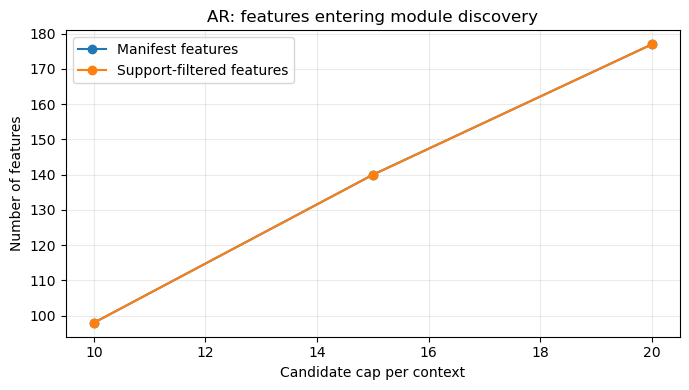

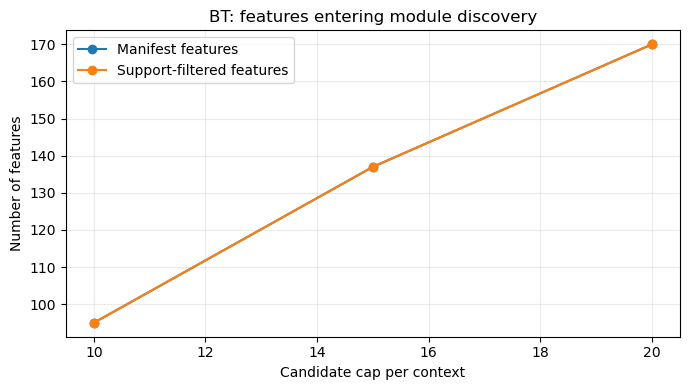

In [10]:
for panel in PANELS:
    sub = (
        cap_summary.loc[cap_summary["panel"].eq(panel)]
        .sort_values("cap")
        .copy()
    )

    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(
        sub["cap"],
        sub["n_manifest_features"],
        marker="o",
        label="Manifest features",
    )
    ax.plot(
        sub["cap"],
        sub["n_support_filtered_features"],
        marker="o",
        label="Support-filtered features",
    )

    ax.set_xlabel("Candidate cap per context")
    ax.set_ylabel("Number of features")
    ax.set_title(f"{panel}: features entering module discovery")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Matrix QC

Before interpreting clustering, confirm that each cap reuses the same cohort/patient structure and that no cap has unexpected missingness.

In [11]:
for cap, cap_obj in prepared.items():
    for panel, obj in cap_obj.items():
        print("=" * 90)
        print(f"CAP {cap} :: {panel}")
        print("=" * 90)
        display(obj["matrix_qc"])

CAP 10 :: AR


,context_matrix_id,cohort,panel,n_patients,n_features_matrix,n_features_corr
0,NAC2020__AR__TURBT__all__median,NAC2020,AR,40,98,98
1,PURE01__AR__TURBT__all__median,PURE01,AR,70,98,98
2,BLASST__AR__TURBT__all__median,BLASST,AR,37,98,86
3,No-NAC__AR__TURBT__all__median,No-NAC,AR,56,98,98


CAP 10 :: BT


,context_matrix_id,cohort,panel,n_patients,n_features_matrix,n_features_corr
0,NAC2020__BT__TURBT__all__median,NAC2020,BT,38,95,95
1,PURE01__BT__TURBT__all__median,PURE01,BT,66,95,95
2,BLASST__BT__TURBT__all__median,BLASST,BT,39,95,87
3,No-NAC__BT__TURBT__all__median,No-NAC,BT,57,95,95


CAP 15 :: AR


...

,context_matrix_id,cohort,panel,n_patients,n_features_matrix,n_features_corr
0,NAC2020__BT__TURBT__all__median,NAC2020,BT,38,137,137
1,PURE01__BT__TURBT__all__median,PURE01,BT,66,137,137
2,BLASST__BT__TURBT__all__median,BLASST,BT,39,137,128
3,No-NAC__BT__TURBT__all__median,No-NAC,BT,57,137,137


CAP 20 :: AR


,context_matrix_id,cohort,panel,n_patients,n_features_matrix,n_features_corr
0,NAC2020__AR__TURBT__all__median,NAC2020,AR,40,177,177
1,PURE01__AR__TURBT__all__median,PURE01,AR,70,177,177
2,BLASST__AR__TURBT__all__median,BLASST,AR,37,177,153
3,No-NAC__AR__TURBT__all__median,No-NAC,AR,56,177,177


CAP 20 :: BT


,context_matrix_id,cohort,panel,n_patients,n_features_matrix,n_features_corr
0,NAC2020__BT__TURBT__all__median,NAC2020,BT,38,170,170
1,PURE01__BT__TURBT__all__median,PURE01,BT,66,170,170
2,BLASST__BT__TURBT__all__median,BLASST,BT,39,170,161
3,No-NAC__BT__TURBT__all__median,No-NAC,BT,57,170,170


# Corrected v9 semantic diagnostics

The following cells rebuild the semantic ontology from the **corrected v8.2 grammar parser**.

The three semantic views are intentionally distinct:

### Primitive
Cell identity only.

### Tissue-aware
Cell identity + tissue compartment.

\[
S_{tissue}=0.70S_{cell}+0.30S_{tissue}
\]

### Measure-aware
Cell identity + measurement subtype / summary.

\[
S_{measure}=0.70S_{cell}+0.30S_{metric}
\]

The metric component is graded. For example, for NN summaries:

- Mean vs Median: highly similar
- Mean vs Q1/Q3: moderately/highly similar
- Mean vs Min/Max: less similar
- Mean vs SD: weakly similar

This semantic grading is **only for evaluating module coherence**. It does not imply those measures are interchangeable for microcompression.

In [12]:
# Load corrected feature parser.

spec = importlib.util.spec_from_file_location(
    "stage2_feature_parser_v8_2_notebook",
    PARSER_PATH,
)
parser_v9 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(parser_v9)

print("Loaded:", PARSER_PATH)

Loaded: /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules/stage2_feature_parser_v8_2.py


In [13]:
def parse_manifest_ontology(manifest, feature_uids):
    meta = (
        manifest
        .drop_duplicates("feature_uid")
        .set_index("feature_uid", drop=False)
    )

    rows = []

    for uid in map(str, feature_uids):
        if uid in meta.index:
            r = meta.loc[uid]
            feature = r.get("feature")
            source = r.get("feature_source")
            group = r.get("feature_group")
        else:
            parts = uid.split("|", 2)
            source = parts[0] if len(parts) == 3 else None
            group = parts[1] if len(parts) == 3 else None
            feature = parts[2] if len(parts) == 3 else uid

        p = parser_v9.parse_feature(
            str(feature),
            feature_source=None if pd.isna(source) else str(source),
            feature_group=None if pd.isna(group) else str(group),
        )

        rows.append({
            "feature_uid": uid,
            "feature": feature,
            "feature_source": source,
            "feature_group": group,
            "parse_status": p.get("parse_status"),
            "candidate_eligible": p.get("candidate_eligible", True),
            "feature_type": p.get("feature_type"),
            "feature_subtype": p.get("feature_subtype"),
            "summary_stat": p.get("summary_stat"),
            "compartment": p.get("compartment"),
            "cells": tuple(sorted(p.get("cells", []) or [])),
            "states": tuple(sorted(p.get("states", []) or [])),
            "lineages": tuple(sorted(p.get("lineages", []) or [])),
            "metric_params": p.get("metric_params", {}) or {},
        })

    return pd.DataFrame(rows)

## 9. Similarity definitions

These values are intentionally explicit so they can be revised after inspecting the results.

In [14]:
def jaccard_set(a, b, empty_value=0.0):
    a = set(a)
    b = set(b)

    if not a and not b:
        return float(empty_value)

    union = a | b
    if not union:
        return float(empty_value)

    return len(a & b) / len(union)


def tissue_similarity(a, b):
    if a is None or pd.isna(a):
        return 0.0
    if b is None or pd.isna(b):
        return 0.0

    a = str(a).lower()
    b = str(b).lower()

    if a == b:
        return 1.0

    if "all" in {a, b}:
        return 0.50

    # Tumor/Epi vs Stroma are anatomically distinct.
    return 0.0


SUMMARY_SIM = {}

def set_summary_pair(a, b, score):
    SUMMARY_SIM[(a, b)] = score
    SUMMARY_SIM[(b, a)] = score

for s in ["mean", "median", "q1", "q3", "min", "max", "sd"]:
    set_summary_pair(s, s, 1.0)

set_summary_pair("mean", "median", 0.95)

for loc in ["mean", "median"]:
    for q in ["q1", "q3"]:
        set_summary_pair(loc, q, 0.75)

set_summary_pair("q1", "q3", 0.65)

set_summary_pair("q1", "min", 0.75)
set_summary_pair("q3", "max", 0.75)
set_summary_pair("q1", "max", 0.30)
set_summary_pair("q3", "min", 0.30)

for loc in ["mean", "median"]:
    for ext in ["min", "max"]:
        set_summary_pair(loc, ext, 0.45)

set_summary_pair("min", "max", 0.25)

for other in ["mean", "median", "q1", "q3", "min", "max"]:
    set_summary_pair("sd", other, 0.20)


def summary_similarity(a, b):
    if a is None or pd.isna(a):
        return 1.0 if (b is None or pd.isna(b)) else 0.50

    if b is None or pd.isna(b):
        return 0.50

    a = str(a).lower()
    b = str(b).lower()

    if a == b:
        return 1.0

    return SUMMARY_SIM.get((a, b), 0.40)


COMPOSITION_SUBTYPE_SIM = {
    ("count", "density"): 0.80,
    ("density", "proportion"): 0.65,
    ("count", "proportion"): 0.55,
    ("ratio", "density"): 0.35,
    ("ratio", "proportion"): 0.35,
    ("ratio", "count"): 0.25,
}

ATHENA_INTERACTION_SUBTYPES = {
    "interaction_diff",
    "interaction_z",
    "interaction_p",
}

ATHENA_DIVERSITY_SUBTYPES = {
    "richness",
    "shannon",
    "simpson",
    "renyi",
    "hill",
    "quadratic",
    "rao",
}


def symmetric_lookup(mapping, a, b, default):
    if (a, b) in mapping:
        return mapping[(a, b)]
    if (b, a) in mapping:
        return mapping[(b, a)]
    return default


def subtype_similarity(row_a, row_b):
    type_a = str(row_a["feature_type"])
    type_b = str(row_b["feature_type"])
    sub_a = str(row_a["feature_subtype"])
    sub_b = str(row_b["feature_subtype"])

    if type_a == type_b and sub_a == sub_b:
        base = 1.0

    elif type_a == "nearest_neighbor" and type_b == "nearest_neighbor":
        base = 1.0

    elif type_a == "composition" and type_b == "composition":
        base = symmetric_lookup(
            COMPOSITION_SUBTYPE_SIM,
            sub_a,
            sub_b,
            0.20,
        )

    elif (
        sub_a in ATHENA_INTERACTION_SUBTYPES
        and sub_b in ATHENA_INTERACTION_SUBTYPES
    ):
        if {sub_a, sub_b} == {"interaction_diff", "interaction_z"}:
            base = 0.75
        else:
            base = 0.35

    elif (
        sub_a in ATHENA_DIVERSITY_SUBTYPES
        and sub_b in ATHENA_DIVERSITY_SUBTYPES
    ):
        base = 0.60

    elif (
        "infiltration" in {sub_a, sub_b}
        and (
            sub_a in ATHENA_INTERACTION_SUBTYPES
            or sub_b in ATHENA_INTERACTION_SUBTYPES
        )
    ):
        base = 0.35

    elif type_a == type_b == "triad":
        base = 0.70

    elif type_a == type_b:
        base = 0.30

    else:
        base = 0.05

    # Summary statistic refines the measure comparison.
    ssim = summary_similarity(
        row_a.get("summary_stat"),
        row_b.get("summary_stat"),
    )

    # If neither has a summary statistic, subtype similarity is sufficient.
    no_summary_a = row_a.get("summary_stat") is None or pd.isna(row_a.get("summary_stat"))
    no_summary_b = row_b.get("summary_stat") is None or pd.isna(row_b.get("summary_stat"))

    if no_summary_a and no_summary_b:
        return float(base)

    return float(0.70 * base + 0.30 * ssim)

## 10. Build primitive, tissue-aware, and measure-aware similarity matrices

In [15]:
def build_semantic_matrices_v9(ontology):
    ont = ontology.drop_duplicates("feature_uid").set_index("feature_uid")
    features = ont.index.astype(str).tolist()

    primitive = pd.DataFrame(
        0.0,
        index=features,
        columns=features,
    )
    tissue_aware = primitive.copy()
    measure_aware = primitive.copy()

    for i, f1 in enumerate(features):
        r1 = ont.loc[f1]

        for j in range(i, len(features)):
            f2 = features[j]
            r2 = ont.loc[f2]

            cell_sim = jaccard_set(
                r1["cells"],
                r2["cells"],
                empty_value=0.0,
            )

            tissue_sim = tissue_similarity(
                r1["compartment"],
                r2["compartment"],
            )

            metric_sim = subtype_similarity(r1, r2)

            prim = cell_sim
            tis = 0.70 * cell_sim + 0.30 * tissue_sim
            met = 0.70 * cell_sim + 0.30 * metric_sim

            primitive.loc[f1, f2] = primitive.loc[f2, f1] = prim
            tissue_aware.loc[f1, f2] = tissue_aware.loc[f2, f1] = tis
            measure_aware.loc[f1, f2] = measure_aware.loc[f2, f1] = met

    for mat in [primitive, tissue_aware, measure_aware]:
        np.fill_diagonal(mat.values, 1.0)

    return {
        "primitive": primitive,
        "tissue_aware": tissue_aware,
        "measure_aware": measure_aware,
    }

## 11. Recalculate the complete k diagnostics

The statistical silhouette uses the exact saved row-Spearman clustering distance matrix from Stage 2B.

The semantic silhouettes use the same membership assignments but are scored against the corrected v9 semantic distance matrices.

In [16]:
def safe_silhouette_precomputed(distance_df, labels):
    labels = np.asarray(labels)
    n = len(labels)
    n_clusters = len(np.unique(labels))

    if n < 3 or n_clusters < 2 or n_clusters >= n:
        return np.nan

    D = np.asarray(distance_df, dtype=float)

    if not np.isfinite(D).all():
        return np.nan

    np.fill_diagonal(D, 0.0)

    try:
        return float(
            silhouette_score(
                D,
                labels,
                metric="precomputed",
            )
        )
    except Exception:
        return np.nan


def cluster_size_stats(labels):
    s = pd.Series(labels).value_counts()

    if s.empty:
        return {
            "actual_k": 0,
            "max_cluster_fraction": np.nan,
            "singleton_fraction": np.nan,
            "singleton_feature_fraction": np.nan,
            "median_cluster_size": np.nan,
            "n_singletons": 0,
        }

    n_singletons = int((s == 1).sum())

    return {
        "actual_k": int(len(s)),
        "max_cluster_fraction": float(s.max() / s.sum()),
        "singleton_fraction": float(n_singletons / len(s)),
        "singleton_feature_fraction": float(n_singletons / s.sum()),
        "median_cluster_size": float(s.median()),
        "n_singletons": n_singletons,
    }


def evaluate_k_v9(obj, panel, cap):
    features = obj["consensus_filtered"].index.astype(str).tolist()

    ontology = parse_manifest_ontology(
        obj["manifest_used"],
        features,
    )

    bad = ontology[
        ontology["parse_status"].astype(str).ne("ok")
    ]

    if len(bad):
        display(bad)
        raise RuntimeError(
            f"{len(bad)} parser failures for cap={cap} panel={panel}"
        )

    semantic = build_semantic_matrices_v9(ontology)

    D_stat = (
        obj["clustering_distance"]
        .loc[features, features]
        .copy()
    )

    D_primitive = 1.0 - semantic["primitive"]
    D_tissue = 1.0 - semantic["tissue_aware"]
    D_measure = 1.0 - semantic["measure_aware"]

    for D in [D_primitive, D_tissue, D_measure]:
        np.fill_diagonal(D.values, 0.0)

    mem_all = obj["memberships_all_k"].copy()

    rows = []

    for k in sorted(
        pd.to_numeric(
            mem_all["requested_k"],
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .unique()
    ):
        mem = (
            mem_all[
                pd.to_numeric(
                    mem_all["requested_k"],
                    errors="coerce",
                ).eq(k)
            ]
            .drop_duplicates("feature_uid")
            .set_index("feature_uid")
            .reindex(features)
        )

        label_col = (
            "raw_cluster_id"
            if "raw_cluster_id" in mem.columns
            else "module_num"
        )

        if mem[label_col].isna().any():
            continue

        labels = mem[label_col].astype(int).to_numpy()

        rows.append({
            "cap": cap,
            "panel": panel,
            "requested_k": int(k),
            "n_features": len(features),
            "stat_silhouette": safe_silhouette_precomputed(
                D_stat,
                labels,
            ),
            "primitive_semantic_silhouette": safe_silhouette_precomputed(
                D_primitive.loc[features, features],
                labels,
            ),
            "tissue_aware_semantic_silhouette": safe_silhouette_precomputed(
                D_tissue.loc[features, features],
                labels,
            ),
            "measure_aware_semantic_silhouette": safe_silhouette_precomputed(
                D_measure.loc[features, features],
                labels,
            ),
            **cluster_size_stats(labels),
        })

    diag = pd.DataFrame(rows)

    return {
        "k_diagnostics": diag,
        "ontology": ontology,
        "semantic_matrices": semantic,
    }

In [17]:
corrected = {}

for cap, cap_obj in prepared.items():
    corrected[cap] = {}

    for panel, obj in cap_obj.items():
        print(f"Evaluating cap={cap}, panel={panel} ...")

        corrected[cap][panel] = evaluate_k_v9(
            obj,
            panel=panel,
            cap=cap,
        )

        display(
            corrected[cap][panel]["k_diagnostics"].head()
        )

Evaluating cap=10, panel=AR ...


,cap,panel,requested_k,n_features,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,measure_aware_semantic_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,10,AR,4,98,0.572671,-0.073596,-0.067812,-0.057323,4,0.591837,0.000000,0.000000,14.0,0
1,10,AR,5,98,0.572091,-0.152169,-0.093800,-0.103115,5,0.591837,0.000000,0.000000,12.0,0
2,10,AR,6,98,0.547461,-0.209902,-0.169169,-0.153182,6,0.591837,0.166667,0.010204,11.5,1
3,10,AR,7,98,0.509537,-0.211779,-0.161984,-0.149223,7,0.510204,0.142857,0.010204,11.0,1
4,10,AR,8,98,0.538439,-0.215526,-0.164616,-0.150526,8,0.510204,0.125000,0.010204,7.5,1


Evaluating cap=10, panel=BT ...


,cap,panel,requested_k,n_features,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,measure_aware_semantic_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,10,BT,4,95,0.467460,-0.078798,-0.047226,-0.025330,4,0.442105,0.0,0.0,23.5,0
1,10,BT,5,95,0.444753,-0.127540,-0.104024,-0.064236,5,0.442105,0.0,0.0,7.0,0
2,10,BT,6,95,0.368892,-0.149228,-0.108352,-0.070087,6,0.389474,0.0,0.0,6.5,0
3,10,BT,7,95,0.351031,-0.193354,-0.143055,-0.106405,7,0.389474,0.0,0.0,5.0,0
4,10,BT,8,95,0.319519,-0.222271,-0.172182,-0.127201,8,0.389474,0.0,0.0,4.5,0


Evaluating cap=15, panel=AR ...


...

,cap,panel,requested_k,n_features,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,measure_aware_semantic_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,15,BT,4,137,0.521152,-0.054780,-0.019576,-0.002872,4,0.459854,0.000000,0.000000,32.5,0
1,15,BT,5,137,0.518587,-0.099083,-0.073300,-0.034244,5,0.459854,0.000000,0.000000,13.0,0
2,15,BT,6,137,0.464711,-0.127976,-0.106762,-0.059477,6,0.445255,0.000000,0.000000,11.0,0
3,15,BT,7,137,0.429956,-0.150542,-0.140248,-0.069711,7,0.445255,0.142857,0.007299,9.0,1
4,15,BT,8,137,0.422566,-0.163752,-0.146912,-0.079529,8,0.445255,0.125000,0.007299,6.5,1


Evaluating cap=20, panel=AR ...


,cap,panel,requested_k,n_features,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,measure_aware_semantic_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,20,AR,4,177,0.491451,-0.153250,-0.135122,-0.108274,4,0.672316,0.250000,0.00565,28.5,1
1,20,AR,5,177,0.481643,-0.205182,-0.184039,-0.160965,5,0.672316,0.200000,0.00565,23.0,1
2,20,AR,6,177,0.476599,-0.231396,-0.193313,-0.179058,6,0.672316,0.166667,0.00565,11.5,1
3,20,AR,7,177,0.416544,-0.230131,-0.184347,-0.177167,7,0.536723,0.142857,0.00565,19.0,1
4,20,AR,8,177,0.432837,-0.243079,-0.194385,-0.186860,8,0.536723,0.125000,0.00565,15.0,1


Evaluating cap=20, panel=BT ...


,cap,panel,requested_k,n_features,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,measure_aware_semantic_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,20,BT,4,170,0.501763,-0.026020,-0.000945,0.021459,4,0.441176,0.0,0.0,40.0,0
1,20,BT,5,170,0.466315,-0.062026,-0.053891,0.000277,5,0.441176,0.0,0.0,16.0,0
2,20,BT,6,170,0.441614,-0.130999,-0.126681,-0.048869,6,0.429412,0.0,0.0,15.5,0
3,20,BT,7,170,0.421017,-0.132736,-0.133381,-0.048938,7,0.429412,0.0,0.0,15.0,0
4,20,BT,8,170,0.407559,-0.148692,-0.140210,-0.062098,8,0.429412,0.0,0.0,8.5,0


## 12. Save corrected v9 k diagnostics

These files live beside the prepared cap outputs and are clearly distinguished from any old semantic diagnostics.

In [18]:
for cap, cap_obj in corrected.items():
    for panel, res in cap_obj.items():
        pdir = PREPARED_ROOT / f"cap{cap:03d}__rho0p9" / panel

        res["k_diagnostics"].to_csv(
            pdir / f"{panel}_k_selection_diagnostics_v9_corrected.csv",
            index=False,
        )

        res["ontology"].to_csv(
            pdir / f"{panel}_feature_ontology_v9_corrected.csv",
            index=False,
        )

        print(
            "SAVED:",
            pdir / f"{panel}_k_selection_diagnostics_v9_corrected.csv"
        )

SAVED: /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared/cap010__rho0p9/AR/AR_k_selection_diagnostics_v9_corrected.csv
SAVED: /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared/cap010__rho0p9/BT/BT_k_selection_diagnostics_v9_corrected.csv
SAVED: /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared/cap015__rho0p9/AR/AR_k_selection_diagnostics_v9_corrected.csv
SAVED: /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared/cap015__rho0p9/BT/BT_k_selection_diagnostics_v9_corrected.csv
SAVED: /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared/cap020__rho0p9/AR/AR_k_selection_diagnostics_v9_corrected.csv
SAVED: /projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v9/stage2b_cap_sensitivity/prepared/cap020__rho0p9/BT/BT_k_selection_dia

## 13. Combined k diagnostic table

There is deliberately **no automatic composite score** here. First inspect each diagnostic directly.

In [19]:
all_kdiag = []

for cap, cap_obj in corrected.items():
    for panel, res in cap_obj.items():
        all_kdiag.append(res["k_diagnostics"])

all_kdiag = (
    pd.concat(all_kdiag, ignore_index=True)
    if all_kdiag
    else pd.DataFrame()
)

display(
    all_kdiag.sort_values(
        ["panel", "cap", "requested_k"]
    )
)

,cap,panel,requested_k,n_features,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,measure_aware_semantic_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,10,AR,4,98,0.572671,-0.073596,-0.067812,-0.057323,4,0.591837,0.000000,0.000000,14.0,0
1,10,AR,5,98,0.572091,-0.152169,-0.093800,-0.103115,5,0.591837,0.000000,0.000000,12.0,0
2,10,AR,6,98,0.547461,-0.209902,-0.169169,-0.153182,6,0.591837,0.166667,0.010204,11.5,1
3,10,AR,7,98,0.509537,-0.211779,-0.161984,-0.149223,7,0.510204,0.142857,0.010204,11.0,1
4,10,AR,8,98,0.538439,-0.215526,-0.164616,-0.150526,8,0.510204,0.125000,0.010204,7.5,1
5,10,AR,9,98,0.508979,-0.224101,-0.174036,-0.169321,9,0.489796,0.111111,0.010204,7.0,1
6,10,AR,10,98,0.510464,-0.241091,-0.192705,-0.177533,10,0.489796,0.100000,0.010204,6.0,1
7,10,AR,11,98,0.443851,-0.247982,-0.189743,-0.186160,11,0.479592,0.181818,0.020408,5.0,2
8,10,AR,12,98,0.445735,-0.308242,-0.225471,-0.217340,12,0.479592,0.166667,0.020408,4.5,2
9,10,AR,13,98,0.425914,-0.332141,-0.236337,-0.238175,13,0.479592,0.230769,0.030612,4.0,3


## 14. Plot each k diagnostic separately

Desired directions:

- statistical silhouette: **higher**
- primitive semantic silhouette: **higher**
- tissue-aware semantic silhouette: **higher**
- measure-aware semantic silhouette: **higher**
- max cluster fraction: **lower**
- singleton fraction: **lower**

Look for **plateaus and structural breakpoints**, rather than mechanically selecting the absolute optimum of one metric.

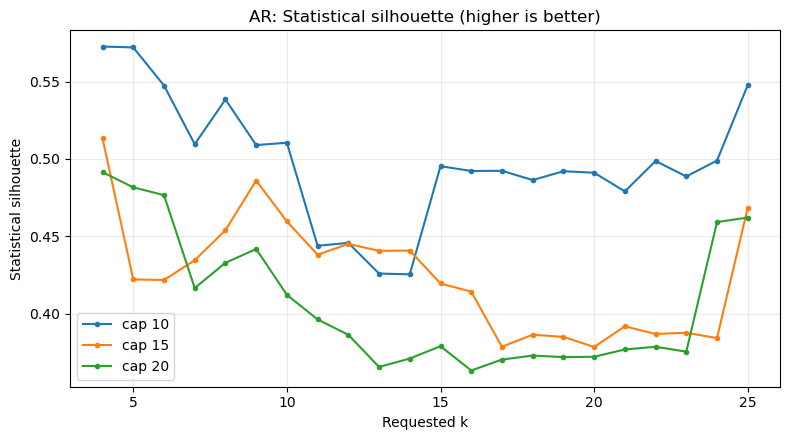

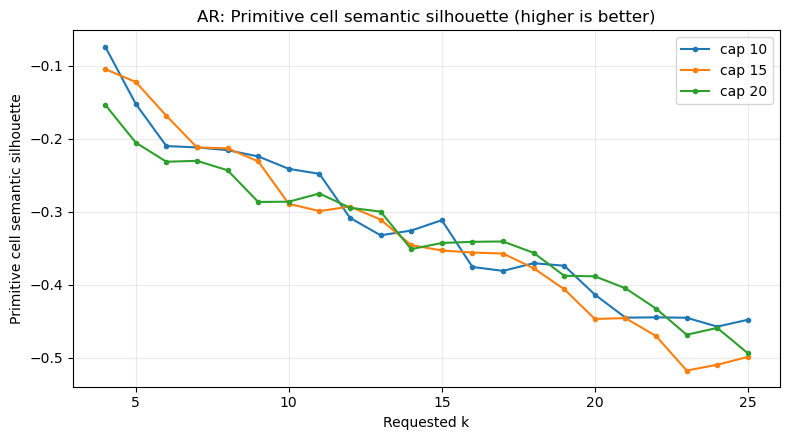

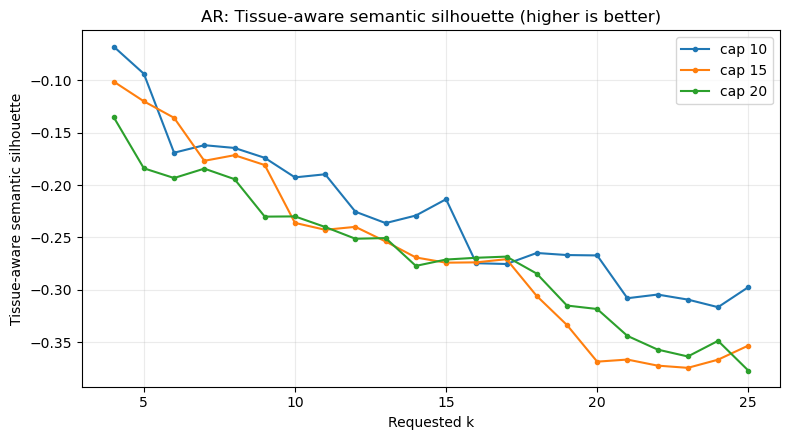

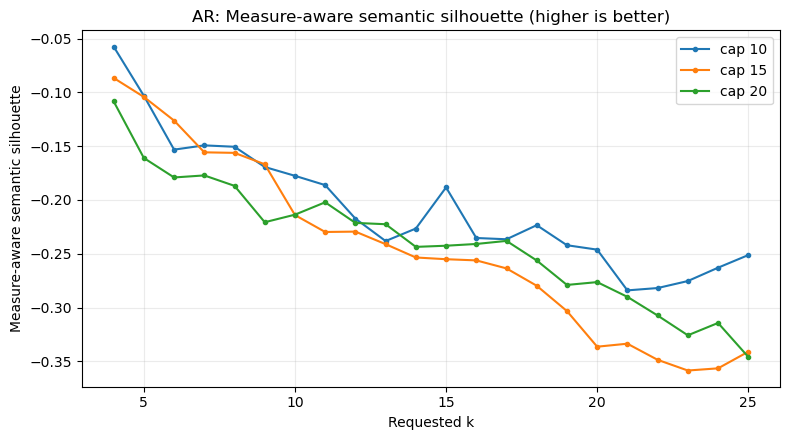

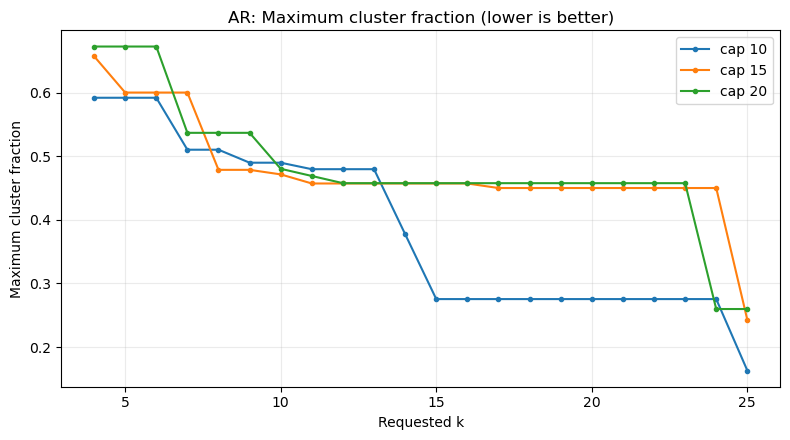

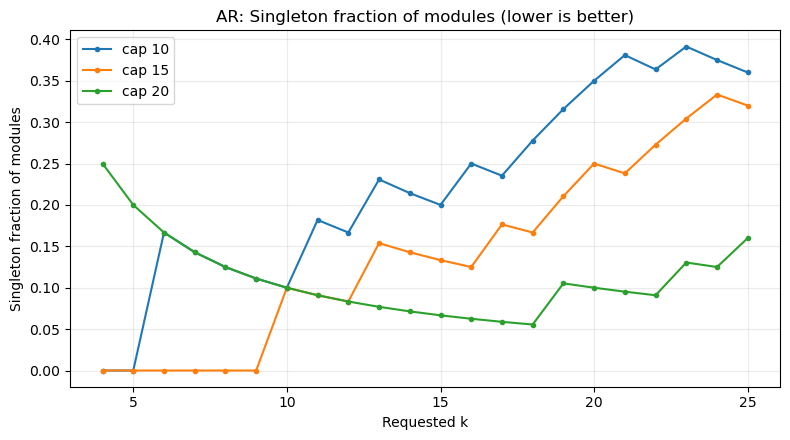

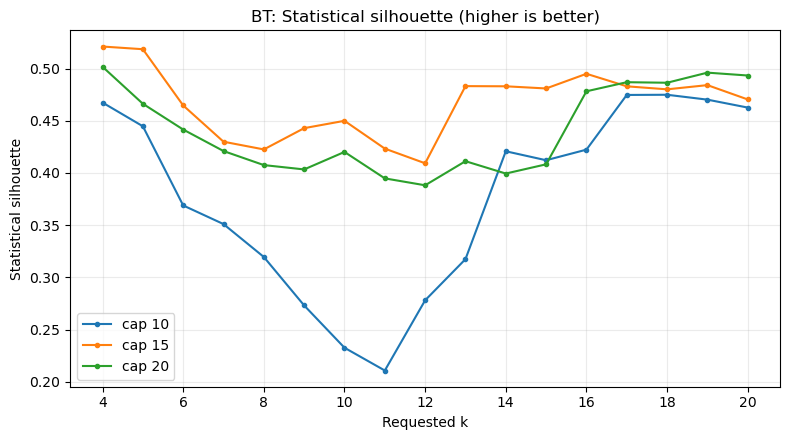

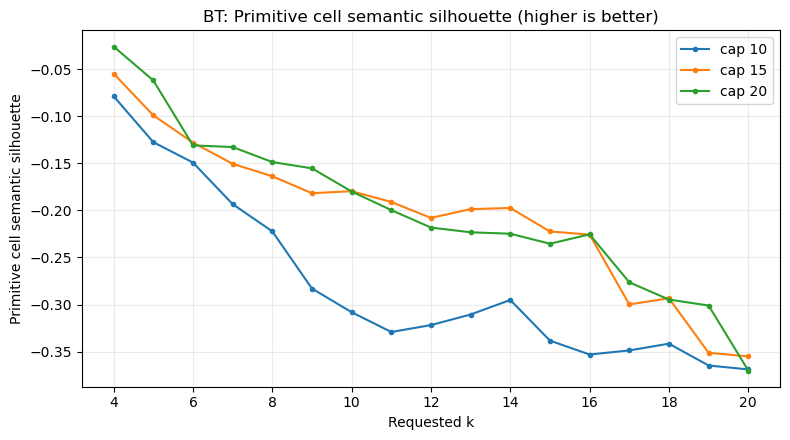

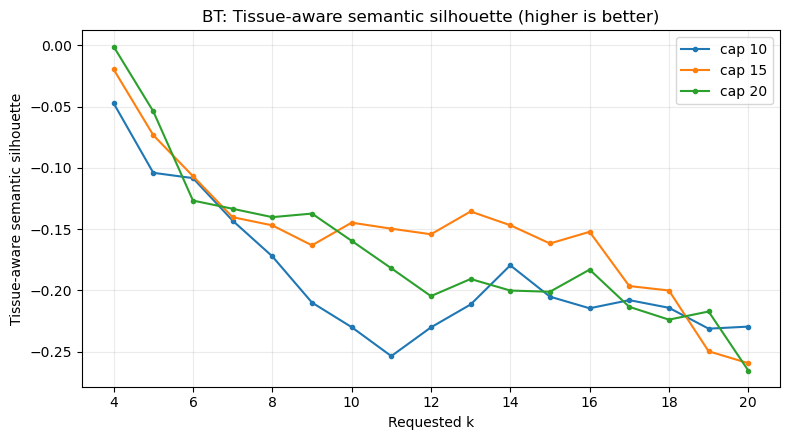

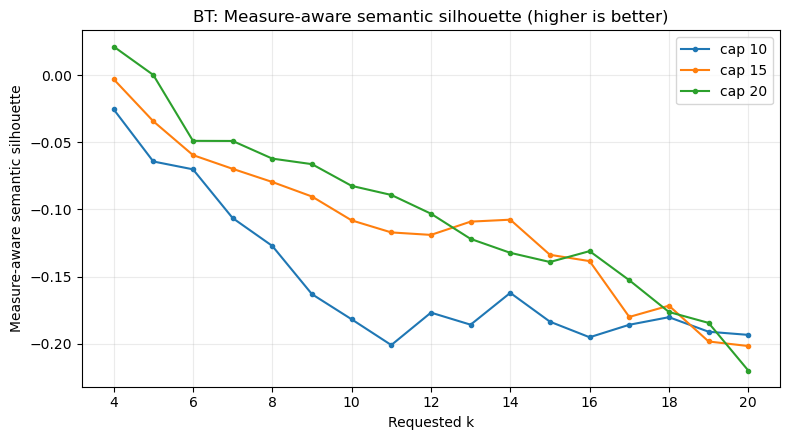

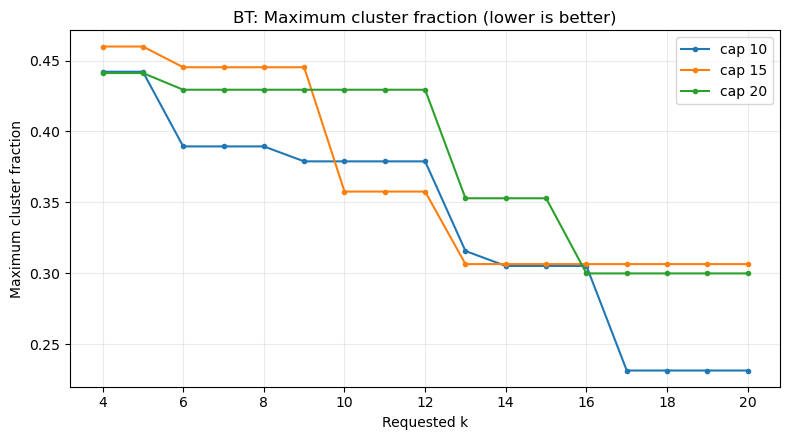

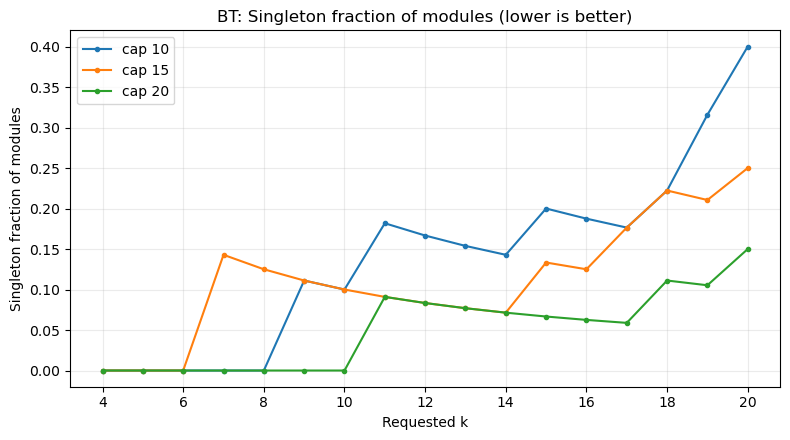

In [20]:
METRICS = [
    ("stat_silhouette", "Statistical silhouette", "higher"),
    ("primitive_semantic_silhouette", "Primitive cell semantic silhouette", "higher"),
    ("tissue_aware_semantic_silhouette", "Tissue-aware semantic silhouette", "higher"),
    ("measure_aware_semantic_silhouette", "Measure-aware semantic silhouette", "higher"),
    ("max_cluster_fraction", "Maximum cluster fraction", "lower"),
    ("singleton_fraction", "Singleton fraction of modules", "lower"),
]

for panel in PANELS:
    panel_df = all_kdiag[
        all_kdiag["panel"].astype(str).eq(panel)
    ].copy()

    if panel_df.empty:
        continue

    for metric, label, direction in METRICS:
        fig, ax = plt.subplots(figsize=(8, 4.5))

        for cap in CAPS:
            x = (
                panel_df[
                    panel_df["cap"].eq(cap)
                ]
                .sort_values("requested_k")
            )

            if x.empty:
                continue

            ax.plot(
                x["requested_k"],
                x[metric],
                marker="o",
                markersize=3,
                label=f"cap {cap}",
            )

        ax.set_xlabel("Requested k")
        ax.set_ylabel(label)
        ax.set_title(
            f"{panel}: {label} ({direction} is better)"
        )
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

## 15. Practical shortlist table

This is not a formal score. It simply makes it easier to inspect k values with tolerable cluster structure.

Edit the guardrails if needed.

In [ ]:
MAX_CLUSTER_FRACTION_GUARDRAIL = 0.35
SINGLETON_FRACTION_GUARDRAIL = 0.20

shortlist = all_kdiag[
    (all_kdiag["max_cluster_fraction"] <= MAX_CLUSTER_FRACTION_GUARDRAIL)
    & (all_kdiag["singleton_fraction"] <= SINGLETON_FRACTION_GUARDRAIL)
].copy()

shortlist = shortlist.sort_values(
    [
        "panel",
        "cap",
        "stat_silhouette",
        "measure_aware_semantic_silhouette",
        "tissue_aware_semantic_silhouette",
    ],
    ascending=[True, True, False, False, False],
)

display(shortlist)

In [21]:
# ============================================================
# DIAGNOSTIC 1: ontology coverage
# ============================================================

import ast
import numpy as np
import pandas as pd

def count_cells(x):
    if isinstance(x, (tuple, list, set)):
        return len(x)

    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0

    s = str(x).strip()

    if s in {"", "()", "[]", "nan", "None"}:
        return 0

    try:
        y = ast.literal_eval(s)
        if isinstance(y, (tuple, list, set)):
            return len(y)
    except Exception:
        pass

    return len([v for v in s.split(";") if v])


rows = []

for cap in CAPS:
    for panel in PANELS:

        if panel not in corrected.get(cap, {}):
            continue

        ont = corrected[cap][panel]["ontology"].copy()

        n_cells = ont["cells"].map(count_cells)

        compartment = (
            ont["compartment"]
            .fillna("")
            .astype(str)
            .str.lower()
        )

        rows.append({
            "cap": cap,
            "panel": panel,
            "n_features": len(ont),

            "n_zero_cell_features": int((n_cells == 0).sum()),
            "frac_zero_cell_features": float((n_cells == 0).mean()),

            "n_one_cell_features": int((n_cells == 1).sum()),
            "n_multi_cell_features": int((n_cells >= 2).sum()),

            "frac_no_compartment": float(
                compartment.isin(["", "none", "nan"]).mean()
            ),
        })


ontology_coverage = pd.DataFrame(rows)

display(
    ontology_coverage.sort_values(
        ["panel", "cap"]
    )
)

,cap,panel,n_features,n_zero_cell_features,frac_zero_cell_features,n_one_cell_features,n_multi_cell_features,frac_no_compartment
0,10,AR,98,6,0.061224,28,64,0.183673
2,15,AR,140,10,0.071429,34,96,0.185714
4,20,AR,177,11,0.062147,41,125,0.192090
1,10,BT,95,3,0.031579,20,72,0.336842
3,15,BT,137,5,0.036496,29,103,0.350365
5,20,BT,170,7,0.041176,34,129,0.335294


In [22]:
for cap in CAPS:
    for panel in PANELS:

        if panel not in corrected.get(cap, {}):
            continue

        print("\n" + "=" * 80)
        print(panel, "CAP", cap)
        print("=" * 80)

        ont = corrected[cap][panel]["ontology"]

        display(
            ont["feature_type"]
            .value_counts(dropna=False)
            .rename_axis("feature_type")
            .reset_index(name="n")
        )


AR CAP 10


,feature_type,n
0,ATHENA_interaction,36
1,composition,22
2,triad,18
3,nearest_neighbor,18
4,ATHENA_diversity,4



BT CAP 10


,feature_type,n
0,nearest_neighbor,32
1,triad,26
2,composition,18
3,ATHENA_interaction,13
4,ATHENA_infiltration,3
5,ATHENA_diversity,3



AR CAP 15


...

,feature_type,n
0,nearest_neighbor,48
1,triad,40
2,composition,23
3,ATHENA_interaction,17
4,ATHENA_diversity,5
5,ATHENA_infiltration,4



AR CAP 20


,feature_type,n
0,ATHENA_interaction,55
1,triad,45
2,composition,35
3,nearest_neighbor,34
4,ATHENA_diversity,8



BT CAP 20


,feature_type,n
0,nearest_neighbor,57
1,triad,49
2,ATHENA_interaction,27
3,composition,25
4,ATHENA_diversity,7
5,ATHENA_infiltration,5


In [23]:
# ============================================================
# DIAGNOSTIC 2: how sparse is cohort pair support?
# ============================================================

support_rows = []

for cap in CAPS:
    for panel in PANELS:

        if panel not in prepared.get(cap, {}):
            continue

        obj = prepared[cap][panel]

        S = obj["pair_support_filtered"].copy()
        C = obj["consensus_filtered"].copy()

        n = len(S)

        if n < 2:
            continue

        offdiag = ~np.eye(n, dtype=bool)

        support_vals = S.to_numpy()[offdiag]
        consensus_vals = C.to_numpy()[offdiag]

        support_rows.append({
            "cap": cap,
            "panel": panel,
            "n_features": n,

            "frac_pairs_support_lt2":
                float(np.mean(support_vals < 2)),

            "frac_pairs_support_eq2":
                float(np.mean(support_vals == 2)),

            "frac_pairs_support_eq3":
                float(np.mean(support_vals == 3)),

            "frac_pairs_support_eq4":
                float(np.mean(support_vals == 4)),

            "frac_consensus_exact_zero":
                float(np.mean(consensus_vals == 0)),
        })


support_sparsity = pd.DataFrame(support_rows)

display(
    support_sparsity.sort_values(
        ["panel", "cap"]
    )
)

,cap,panel,n_features,frac_pairs_support_lt2,frac_pairs_support_eq2,frac_pairs_support_eq3,frac_pairs_support_eq4,frac_consensus_exact_zero
0,10,AR,98,0.0,0.0,0.232064,0.767936,0.0
2,15,AR,140,0.0,0.0,0.229908,0.770092,0.0
4,20,AR,177,0.0,0.0,0.254301,0.745699,0.0
1,10,BT,95,0.0,0.0,0.162150,0.837850,0.0
3,15,BT,137,0.0,0.0,0.127523,0.872477,0.0
5,20,BT,170,0.0,0.0,0.103376,0.896624,0.0


In [24]:
# ============================================================
# DIAGNOSTIC 3:
# Is row-Spearman similarity driven by shared support patterns?
# ============================================================

from scipy.stats import spearmanr


def row_support_jaccard(support):
    B = (support >= 2).astype(int)

    features = B.index
    n = len(features)

    J = np.eye(n)

    for i in range(n):
        a = B.iloc[i].to_numpy(dtype=bool)

        for j in range(i + 1, n):
            b = B.iloc[j].to_numpy(dtype=bool)

            # ignore the two self positions
            mask = np.ones(n, dtype=bool)
            mask[[i, j]] = False

            aa = a[mask]
            bb = b[mask]

            union = np.logical_or(aa, bb).sum()

            if union == 0:
                val = 0.0
            else:
                val = (
                    np.logical_and(aa, bb).sum()
                    / union
                )

            J[i, j] = val
            J[j, i] = val

    return pd.DataFrame(
        J,
        index=features,
        columns=features,
    )


rows = []

for cap in CAPS:
    for panel in PANELS:

        if panel not in prepared.get(cap, {}):
            continue

        obj = prepared[cap][panel]

        D = obj["clustering_distance"].copy()
        S = obj["pair_support_filtered"].copy()

        features = D.index.intersection(S.index)

        D = D.loc[features, features]
        S = S.loc[features, features]

        support_J = row_support_jaccard(S)

        stat_similarity = 1.0 - D

        iu = np.triu_indices(
            len(features),
            k=1,
        )

        rho, p = spearmanr(
            support_J.to_numpy()[iu],
            stat_similarity.to_numpy()[iu],
            nan_policy="omit",
        )

        rows.append({
            "cap": cap,
            "panel": panel,
            "n_features": len(features),
            "rho_support_pattern_vs_stat_similarity": rho,
            "p_value": p,
        })


support_artifact_test = pd.DataFrame(rows)

display(
    support_artifact_test.sort_values(
        ["panel", "cap"]
    )
)

/home/nalabi/miniconda3/envs/cuda6/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


,cap,panel,n_features,rho_support_pattern_vs_stat_similarity,p_value
0,10,AR,98,NaN,NaN
2,15,AR,140,NaN,NaN
4,20,AR,177,NaN,NaN
1,10,BT,95,NaN,NaN
3,15,BT,137,NaN,NaN
5,20,BT,170,NaN,NaN


In [25]:
# ============================================================
# Compare Stage 2B clustering geometry:
# row-Spearman profiles vs direct signed consensus correlation
# ============================================================

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

def make_distance(C, mode):
    C = (
        C.copy()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    if mode == "direct_signed":
        D = 1.0 - C

    elif mode == "direct_abs":
        D = 1.0 - C.abs()

    elif mode == "row_spearman":
        R = (
            C.T
            .corr(method="spearman")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
        )
        D = 1.0 - R

    else:
        raise ValueError(mode)

    D = D.clip(0, 2)

    np.fill_diagonal(D.values, 0.0)

    return D


def make_linkage(D):
    arr = D.to_numpy(dtype=float)

    arr = (arr + arr.T) / 2

    np.fill_diagonal(arr, 0)

    return linkage(
        squareform(arr, checks=False),
        method="average",
    )


def safe_silhouette(D, labels):
    labels = np.asarray(labels)

    if (
        len(np.unique(labels)) < 2
        or len(np.unique(labels)) >= len(labels)
    ):
        return np.nan

    arr = D.to_numpy(dtype=float)

    return silhouette_score(
        arr,
        labels,
        metric="precomputed",
    )


def cluster_summary(labels):
    sizes = pd.Series(labels).value_counts()

    n_singletons = (sizes == 1).sum()

    return {
        "actual_k": len(sizes),

        "max_cluster_fraction":
            sizes.max() / sizes.sum(),

        # fraction of MODULES that are singleton modules
        "singleton_fraction":
            n_singletons / len(sizes),

        # fraction of FEATURES residing in singleton modules
        "singleton_feature_fraction":
            n_singletons / sizes.sum(),

        "median_cluster_size":
            sizes.median(),

        "n_singletons":
            n_singletons,
    }


distance_rows = []
distance_memberships = {}

MODES = [
    "row_spearman",
    "direct_signed",
    # keep absolute only as a diagnostic
    "direct_abs",
]

for cap in CAPS:

    distance_memberships[cap] = {}

    for panel in PANELS:

        if panel not in prepared.get(cap, {}):
            continue

        C = prepared[cap][panel][
            "consensus_filtered"
        ].copy()

        features = C.index.astype(str).tolist()

        distance_memberships[cap][panel] = {}

        k_max = 25 if panel == "AR" else 20

        for mode in MODES:

            D = make_distance(C, mode)
            Z = make_linkage(D)

            distance_memberships[
                cap
            ][panel][mode] = {}

            for k in range(4, min(k_max, len(features) - 1) + 1):

                labels = fcluster(
                    Z,
                    t=k,
                    criterion="maxclust",
                )

                distance_memberships[
                    cap
                ][panel][mode][k] = pd.Series(
                    labels,
                    index=features,
                    name="cluster",
                )

                distance_rows.append({
                    "cap": cap,
                    "panel": panel,
                    "distance_mode": mode,
                    "requested_k": k,

                    "stat_silhouette":
                        safe_silhouette(
                            D,
                            labels,
                        ),

                    **cluster_summary(labels),
                })


distance_comparison = pd.DataFrame(
    distance_rows
)

display(distance_comparison.head())

,cap,panel,distance_mode,requested_k,stat_silhouette,actual_k,max_cluster_fraction,singleton_fraction,singleton_feature_fraction,median_cluster_size,n_singletons
0,10,AR,row_spearman,4,0.572671,4,0.591837,0.000000,0.000000,14.0,0
1,10,AR,row_spearman,5,0.572091,5,0.591837,0.000000,0.000000,12.0,0
2,10,AR,row_spearman,6,0.547461,6,0.591837,0.166667,0.010204,11.5,1
3,10,AR,row_spearman,7,0.509537,7,0.510204,0.142857,0.010204,11.0,1
4,10,AR,row_spearman,8,0.538439,8,0.510204,0.125000,0.010204,7.5,1


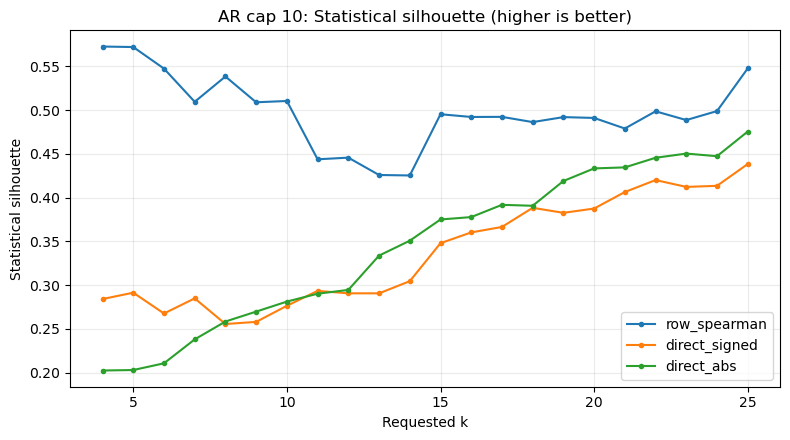

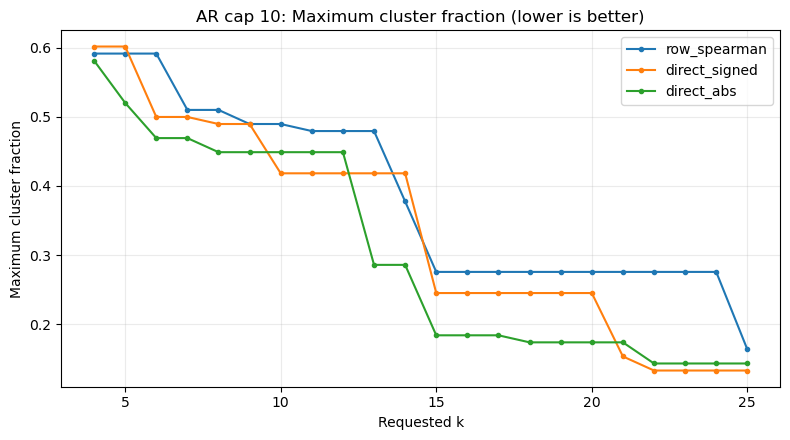

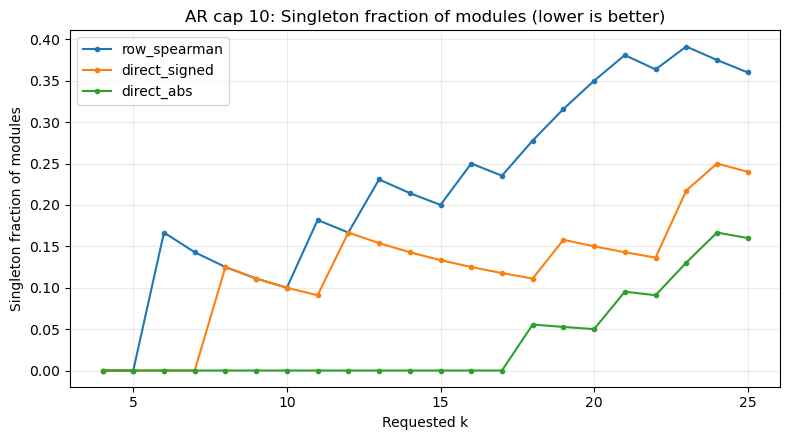

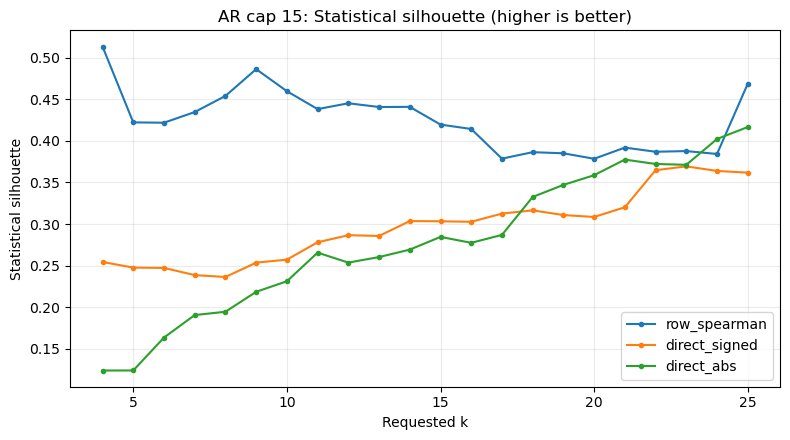

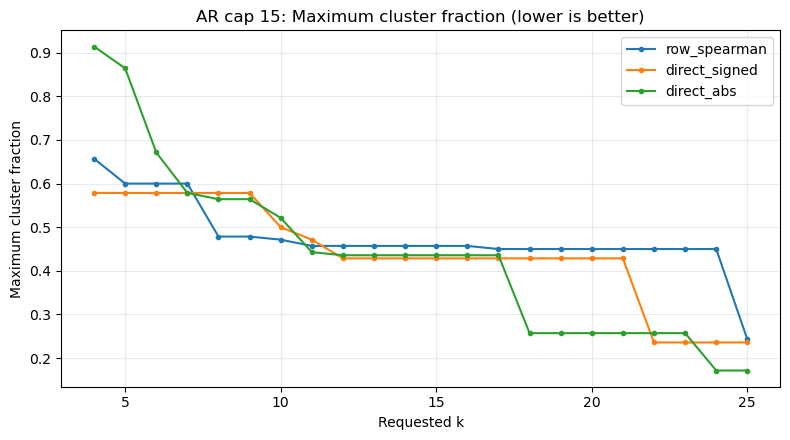

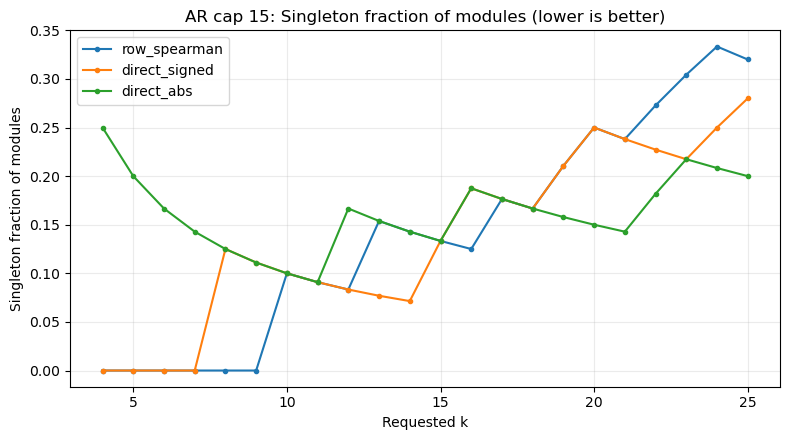

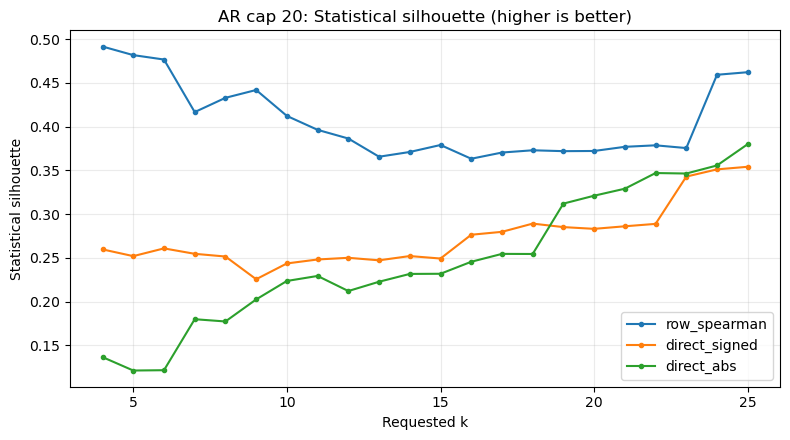

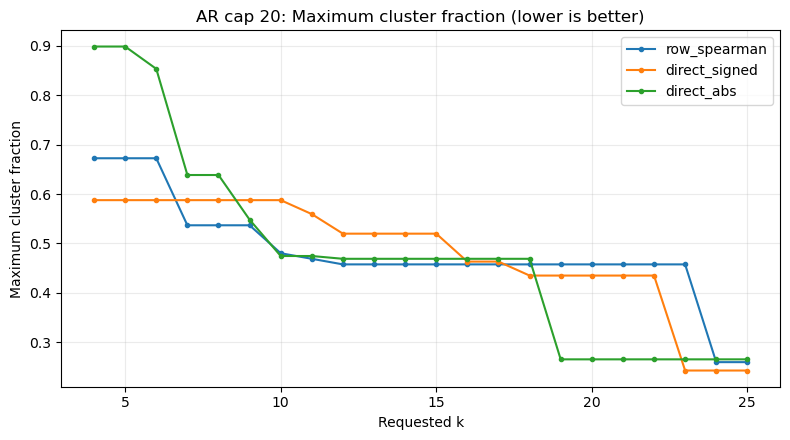

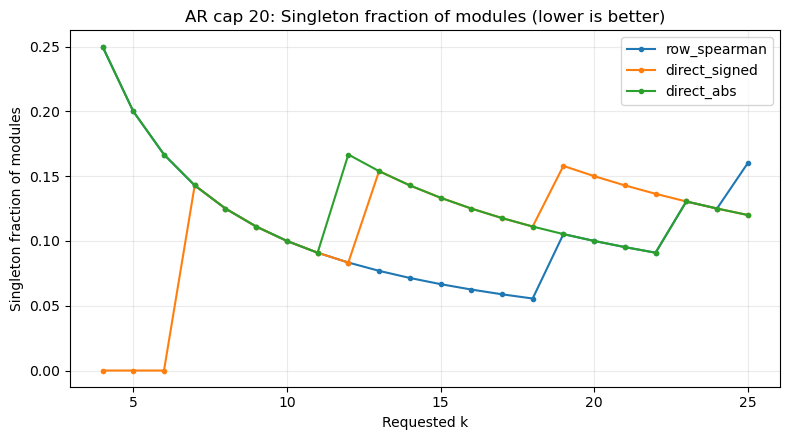

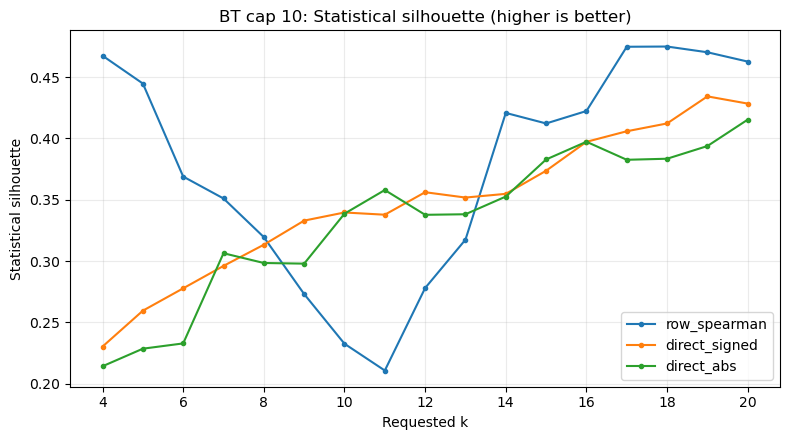

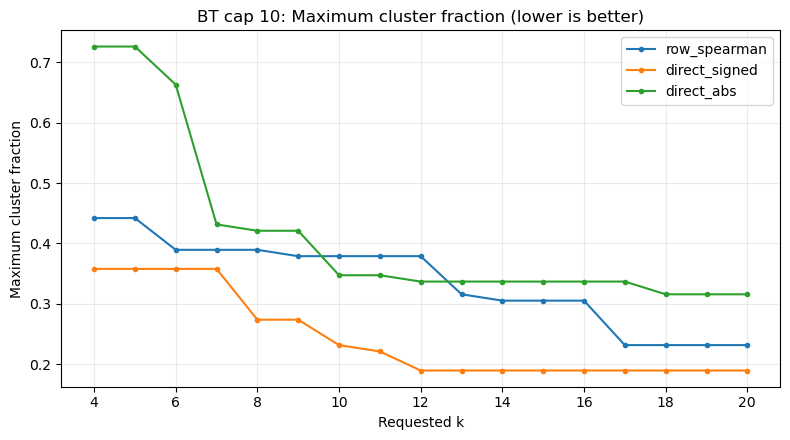

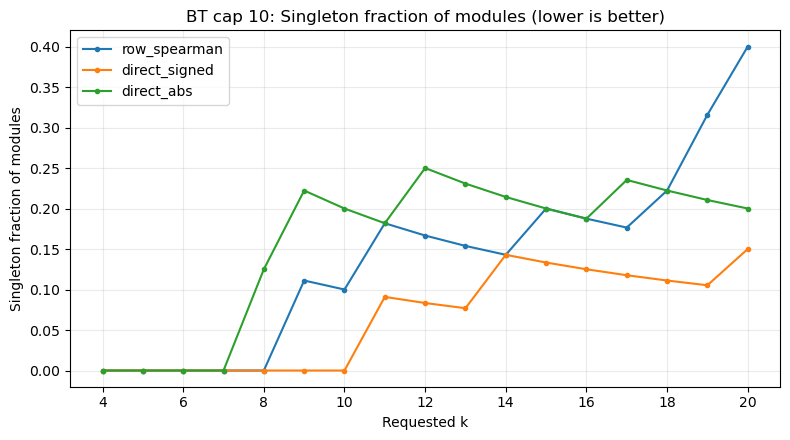

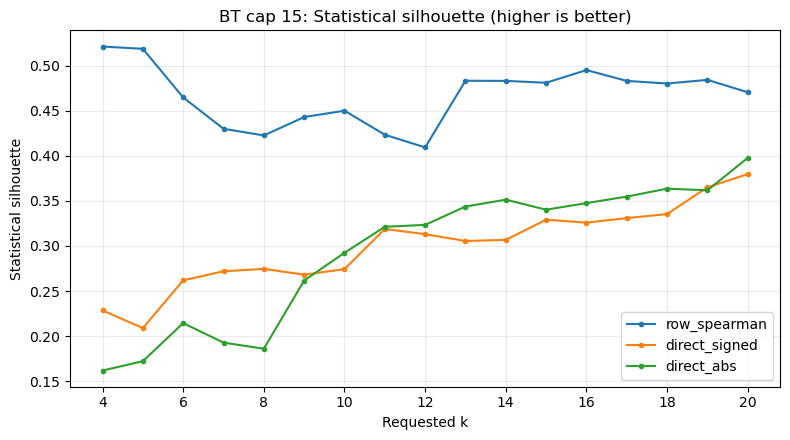

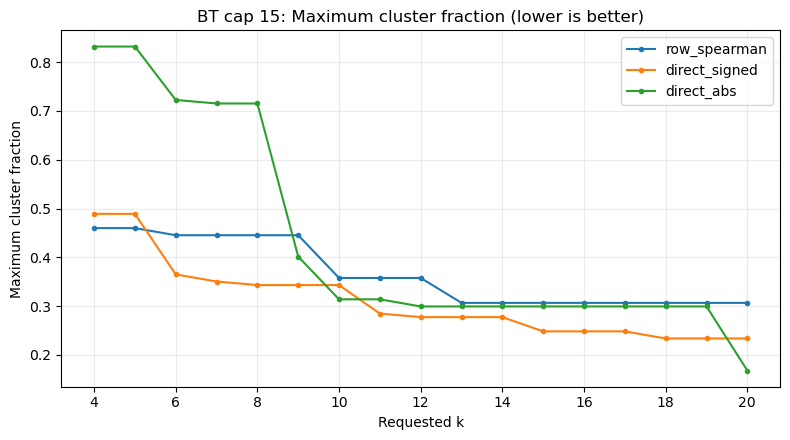

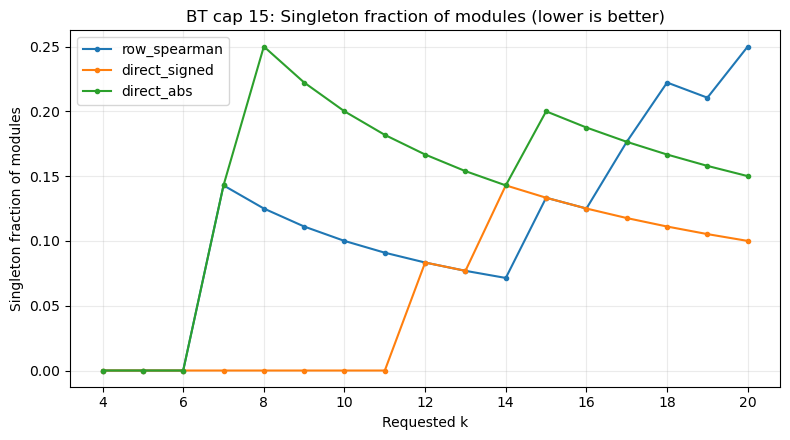

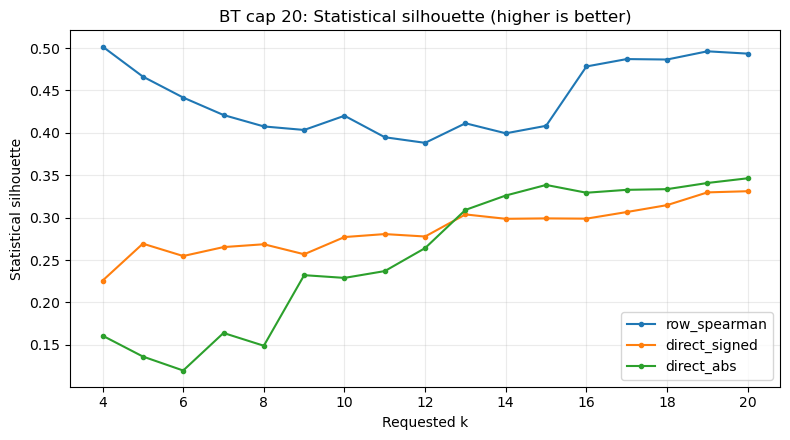

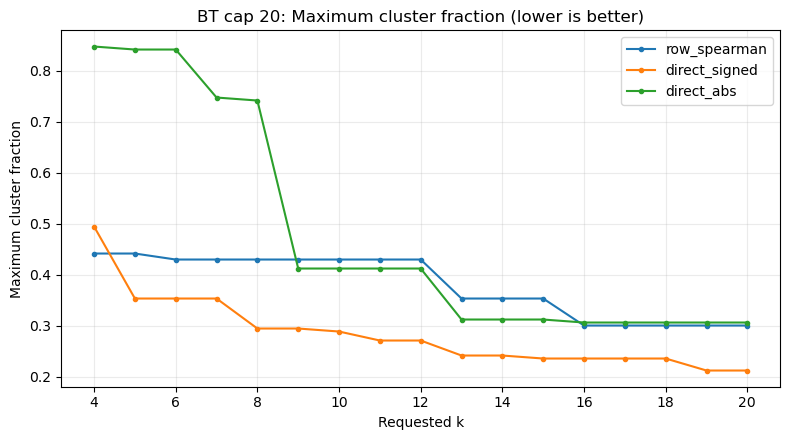

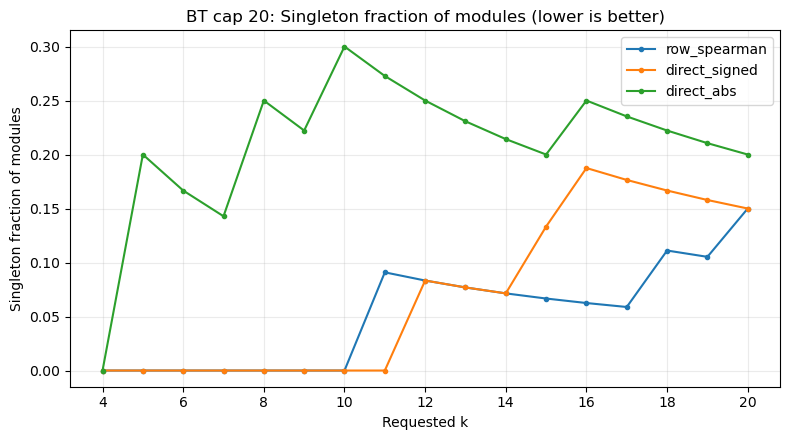

In [26]:
# ============================================================
# Compare clustering modes
# ============================================================

COMPARE_METRICS = [
    (
        "stat_silhouette",
        "Statistical silhouette",
        "higher is better",
    ),
    (
        "max_cluster_fraction",
        "Maximum cluster fraction",
        "lower is better",
    ),
    (
        "singleton_fraction",
        "Singleton fraction of modules",
        "lower is better",
    ),
]

for panel in PANELS:

    for cap in CAPS:

        sub = distance_comparison[
            (distance_comparison["panel"] == panel)
            & (distance_comparison["cap"] == cap)
        ]

        if sub.empty:
            continue

        for metric, ylabel, direction in COMPARE_METRICS:

            fig, ax = plt.subplots(
                figsize=(8, 4.5)
            )

            for mode in MODES:

                x = (
                    sub[
                        sub["distance_mode"] == mode
                    ]
                    .sort_values("requested_k")
                )

                ax.plot(
                    x["requested_k"],
                    x[metric],
                    marker="o",
                    markersize=3,
                    label=mode,
                )

            ax.set_xlabel("Requested k")
            ax.set_ylabel(ylabel)

            ax.set_title(
                f"{panel} cap {cap}: "
                f"{ylabel} ({direction})"
            )

            ax.legend()
            ax.grid(alpha=0.25)

            plt.tight_layout()
            plt.show()

In [30]:
# ============================================================
# Inspect actual cap-10 clusters for k = 2...8
# AR + BT
#
# Shows:
#   - raw features in each cluster
#   - within-cluster consensus correlation
#   - pairwise semantic coherence
#   - cluster-level semantic silhouettes
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import silhouette_samples
from IPython.display import display


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

REVIEW_CAP = 10

# Main comparison:
CLUSTER_MODE = "direct_signed"

# Alternatives:
# CLUSTER_MODE = "row_spearman"
# CLUSTER_MODE = "direct_abs"

K_VALUES = range(4, 9)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def mean_upper_triangle(matrix):
    """
    Mean of off-diagonal upper-triangle values.
    Returns NaN for singleton clusters.
    """
    arr = np.asarray(matrix, dtype=float)

    n = arr.shape[0]

    if n < 2:
        return np.nan

    vals = arr[
        np.triu_indices(n, k=1)
    ]

    vals = vals[np.isfinite(vals)]

    return (
        float(vals.mean())
        if len(vals)
        else np.nan
    )


def semantic_silhouette_by_feature(
    semantic_similarity,
    labels,
):
    """
    Calculate semantic silhouette for every feature.

    semantic_similarity:
        feature × feature similarity matrix

    labels:
        pd.Series indexed by feature_uid
    """

    features = labels.index.astype(str).tolist()

    S = (
        semantic_similarity
        .loc[features, features]
        .copy()
    )

    D = 1.0 - S

    D = D.clip(lower=0)

    arr = D.to_numpy(dtype=float)

    arr = (arr + arr.T) / 2.0

    np.fill_diagonal(arr, 0.0)

    labs = labels.loc[features].to_numpy()

    n_clusters = len(np.unique(labs))

    if (
        n_clusters < 2
        or n_clusters >= len(features)
    ):
        return pd.Series(
            np.nan,
            index=features,
        )

    values = silhouette_samples(
        arr,
        labs,
        metric="precomputed",
    )

    return pd.Series(
        values,
        index=features,
    )


# ------------------------------------------------------------
# Main inspection
# ------------------------------------------------------------

cluster_review = {}
cluster_summary_parts = []
cluster_feature_parts = []


for panel in ["AR", "BT"]:

    print("\n")
    print("#" * 110)
    print(
        f"{panel} | CAP={REVIEW_CAP} | "
        f"CLUSTER MODE={CLUSTER_MODE}"
    )
    print("#" * 110)

    obj = prepared[REVIEW_CAP][panel]

    # Consensus correlation matrix
    C = obj["consensus_filtered"].copy()

    # Corrected semantic matrices
    semantic = corrected[
        REVIEW_CAP
    ][panel]["semantic_matrices"]

    primitive_S = semantic["primitive"]
    tissue_S = semantic["tissue_aware"]
    measure_S = semantic["measure_aware"]

    # Parsed ontology
    ontology = (
        corrected[
            REVIEW_CAP
        ][panel]["ontology"]
        .drop_duplicates("feature_uid")
        .set_index("feature_uid")
    )

    # Raw feature metadata
    manifest = (
        obj["manifest_used"]
        .drop_duplicates("feature_uid")
        .set_index("feature_uid")
    )

    cluster_review[panel] = {}

    for k in K_VALUES:

        # --------------------------------------------
        # Membership generated in previous
        # row_spearman/direct_signed comparison cell
        # --------------------------------------------

        labels = (
            distance_memberships[
                REVIEW_CAP
            ][panel][CLUSTER_MODE][k]
            .copy()
        )

        labels.index = labels.index.astype(str)

        features = labels.index.tolist()

        # --------------------------------------------
        # Semantic silhouette PER FEATURE
        # --------------------------------------------

        primitive_sil = semantic_silhouette_by_feature(
            primitive_S,
            labels,
        )

        tissue_sil = semantic_silhouette_by_feature(
            tissue_S,
            labels,
        )

        measure_sil = semantic_silhouette_by_feature(
            measure_S,
            labels,
        )

        # --------------------------------------------
        # Cluster summaries
        # --------------------------------------------

        summary_rows = []
        feature_rows = []

        for cluster_id in sorted(
            labels.unique()
        ):

            members = labels[
                labels == cluster_id
            ].index.tolist()

            n_members = len(members)

            # Direct biological/statistical coherence
            mean_consensus_rho = mean_upper_triangle(
                C.loc[
                    members,
                    members
                ].to_numpy()
            )

            # ----------------------------------------
            # Pairwise semantic coherence
            #
            # These answer:
            # "How semantically similar are members
            #  of this cluster to one another?"
            # ----------------------------------------

            primitive_coherence = mean_upper_triangle(
                primitive_S.loc[
                    members,
                    members
                ].to_numpy()
            )

            tissue_coherence = mean_upper_triangle(
                tissue_S.loc[
                    members,
                    members
                ].to_numpy()
            )

            measure_coherence = mean_upper_triangle(
                measure_S.loc[
                    members,
                    members
                ].to_numpy()
            )

            # ----------------------------------------
            # Cluster-average semantic silhouettes
            #
            # These answer:
            # "Are these features semantically closer
            #  to THIS cluster than to other clusters?"
            # ----------------------------------------

            primitive_cluster_sil = (
                primitive_sil.loc[members].mean()
            )

            tissue_cluster_sil = (
                tissue_sil.loc[members].mean()
            )

            measure_cluster_sil = (
                measure_sil.loc[members].mean()
            )

            summary_rows.append({
                "panel": panel,
                "cap": REVIEW_CAP,
                "cluster_mode": CLUSTER_MODE,
                "k": k,

                "cluster_id": int(cluster_id),

                "n_features": n_members,

                "mean_within_cluster_consensus_rho":
                    mean_consensus_rho,

                "primitive_semantic_coherence":
                    primitive_coherence,

                "tissue_semantic_coherence":
                    tissue_coherence,

                "measure_semantic_coherence":
                    measure_coherence,

                "primitive_semantic_silhouette":
                    primitive_cluster_sil,

                "tissue_semantic_silhouette":
                    tissue_cluster_sil,

                "measure_semantic_silhouette":
                    measure_cluster_sil,
            })


            # ----------------------------------------
            # Feature-level identities
            # ----------------------------------------

            for uid in members:

                if uid in manifest.index:
                    m = manifest.loc[uid]

                    raw_feature = m.get(
                        "feature",
                        uid,
                    )

                    feature_source = m.get(
                        "feature_source",
                        np.nan,
                    )

                    feature_group = m.get(
                        "feature_group",
                        np.nan,
                    )

                else:
                    raw_feature = uid
                    feature_source = np.nan
                    feature_group = np.nan


                if uid in ontology.index:

                    o = ontology.loc[uid]

                    cells = o.get(
                        "cells",
                        np.nan,
                    )

                    states = o.get(
                        "states",
                        np.nan,
                    )

                    compartment = o.get(
                        "compartment",
                        np.nan,
                    )

                    feature_type = o.get(
                        "feature_type",
                        np.nan,
                    )

                    feature_subtype = o.get(
                        "feature_subtype",
                        np.nan,
                    )

                    summary_stat = o.get(
                        "summary_stat",
                        np.nan,
                    )

                else:

                    cells = np.nan
                    states = np.nan
                    compartment = np.nan
                    feature_type = np.nan
                    feature_subtype = np.nan
                    summary_stat = np.nan


                feature_rows.append({
                    "panel": panel,
                    "cap": REVIEW_CAP,
                    "cluster_mode": CLUSTER_MODE,
                    "k": k,

                    "cluster_id": int(
                        cluster_id
                    ),

                    "feature_uid": uid,

                    "feature":
                        raw_feature,

                    "feature_source":
                        feature_source,

                    "feature_group":
                        feature_group,

                    "cells":
                        cells,

                    "states":
                        states,

                    "compartment":
                        compartment,

                    "feature_type":
                        feature_type,

                    "feature_subtype":
                        feature_subtype,

                    "summary_stat":
                        summary_stat,

                    "primitive_feature_silhouette":
                        primitive_sil.loc[uid],

                    "tissue_feature_silhouette":
                        tissue_sil.loc[uid],

                    "measure_feature_silhouette":
                        measure_sil.loc[uid],
                })


        summary_df = pd.DataFrame(
            summary_rows
        )

        features_df = pd.DataFrame(
            feature_rows
        )

        cluster_review[
            panel
        ][k] = {
            "summary": summary_df,
            "features": features_df,
        }

        cluster_summary_parts.append(
            summary_df
        )

        cluster_feature_parts.append(
            features_df
        )


        # ============================================
        # DISPLAY THIS K
        # ============================================

        print("\n")
        print("=" * 110)
        print(
            f"{panel} :: CAP {REVIEW_CAP} :: "
            f"{CLUSTER_MODE} :: K={k}"
        )
        print("=" * 110)

        display(
            summary_df.sort_values(
                "n_features",
                ascending=False,
            )
            .round(3)
        )


        # --------------------------------------------
        # Then show every cluster's raw features
        # --------------------------------------------

        # for cluster_id in (
        #     summary_df
        #     .sort_values(
        #         "n_features",
        #         ascending=False,
        #     )["cluster_id"]
        # ):

        #     this_cluster = features_df[
        #         features_df[
        #             "cluster_id"
        #         ].eq(cluster_id)
        #     ].copy()

        #     n = len(this_cluster)

        #     print(
        #         f"\n--- Cluster {cluster_id} "
        #         f"(n={n}) ---"
        #     )

        #     display(
        #         this_cluster[
        #             [
        #                 "feature",
        #                 "feature_source",
        #                 "feature_group",
        #                 "cells",
        #                 "states",
        #                 "compartment",
        #                 "feature_type",
        #                 "feature_subtype",
        #                 "summary_stat",
        #             ]
        #         ]
        #         .sort_values(
        #             [
        #                 "feature_group",
        #                 "feature",
        #             ]
        #         )
        #         .reset_index(
        #             drop=True
        #         )
        #     )


# ============================================================
# Combined objects for later inspection
# ============================================================

all_cluster_semantic_summary = (
    pd.concat(
        cluster_summary_parts,
        ignore_index=True,
    )
)

all_cluster_feature_assignments = (
    pd.concat(
        cluster_feature_parts,
        ignore_index=True,
    )
)

print("\nDONE")
print(
    "Summary rows:",
    len(all_cluster_semantic_summary)
)
print(
    "Feature assignment rows:",
    len(all_cluster_feature_assignments)
)



##############################################################################################################
AR | CAP=10 | CLUSTER MODE=direct_signed
##############################################################################################################


AR :: CAP 10 :: direct_signed :: K=4


,panel,cap,cluster_mode,k,cluster_id,n_features,mean_within_cluster_consensus_rho,primitive_semantic_coherence,tissue_semantic_coherence,measure_semantic_coherence,primitive_semantic_silhouette,tissue_semantic_silhouette,measure_semantic_silhouette
0,AR,10,direct_signed,4,1,59,0.295,0.191,0.240,0.226,-0.122,-0.118,-0.105
3,AR,10,direct_signed,4,4,17,0.432,0.337,0.362,0.374,0.059,0.015,0.041
2,AR,10,direct_signed,4,3,12,0.317,0.202,0.282,0.231,-0.076,-0.058,-0.066
1,AR,10,direct_signed,4,2,10,0.345,0.281,0.374,0.417,0.010,0.039,0.125




AR :: CAP 10 :: direct_signed :: K=5


,panel,cap,cluster_mode,k,cluster_id,n_features,mean_within_cluster_consensus_rho,primitive_semantic_coherence,tissue_semantic_coherence,measure_semantic_coherence,primitive_semantic_silhouette,tissue_semantic_silhouette,measure_semantic_silhouette
0,AR,10,direct_signed,5,1,59,0.295,0.191,0.240,0.226,-0.225,-0.173,-0.174
3,AR,10,direct_signed,5,4,13,0.652,0.504,0.534,0.540,0.270,0.227,0.253
2,AR,10,direct_signed,5,3,12,0.317,0.202,0.282,0.231,-0.175,-0.132,-0.155
1,AR,10,direct_signed,5,2,10,0.345,0.281,0.374,0.417,-0.053,-0.015,0.048
4,AR,10,direct_signed,5,5,4,0.497,0.278,0.194,0.340,0.045,-0.031,0.120




AR :: CAP 10 :: direct_signed :: K=6


...



BT :: CAP 10 :: direct_signed :: K=7


,panel,cap,cluster_mode,k,cluster_id,n_features,mean_within_cluster_consensus_rho,primitive_semantic_coherence,tissue_semantic_coherence,measure_semantic_coherence,primitive_semantic_silhouette,tissue_semantic_silhouette,measure_semantic_silhouette
1,BT,10,direct_signed,7,2,34,0.300,0.198,0.164,0.281,-0.320,-0.267,-0.262
2,BT,10,direct_signed,7,3,19,0.418,0.164,0.273,0.203,-0.188,-0.159,-0.209
6,BT,10,direct_signed,7,7,18,0.388,0.270,0.382,0.350,-0.134,-0.007,-0.012
5,BT,10,direct_signed,7,6,12,0.555,0.424,0.572,0.454,-0.212,0.192,-0.038
0,BT,10,direct_signed,7,1,6,0.493,0.533,0.373,0.564,0.429,0.229,0.337
3,BT,10,direct_signed,7,4,3,0.899,1.000,0.700,0.974,1.000,0.524,0.956
4,BT,10,direct_signed,7,5,3,0.764,0.556,0.589,0.689,0.345,0.339,0.534




BT :: CAP 10 :: direct_signed :: K=8


,panel,cap,cluster_mode,k,cluster_id,n_features,mean_within_cluster_consensus_rho,primitive_semantic_coherence,tissue_semantic_coherence,measure_semantic_coherence,primitive_semantic_silhouette,tissue_semantic_silhouette,measure_semantic_silhouette
2,BT,10,direct_signed,8,3,26,0.390,0.252,0.190,0.348,-0.291,-0.240,-0.192
3,BT,10,direct_signed,8,4,19,0.418,0.164,0.273,0.203,-0.193,-0.159,-0.209
7,BT,10,direct_signed,8,8,18,0.388,0.270,0.382,0.350,-0.136,-0.036,-0.012
6,BT,10,direct_signed,8,7,12,0.555,0.424,0.572,0.454,-0.217,0.191,-0.038
1,BT,10,direct_signed,8,2,8,0.415,0.173,0.233,0.205,-0.310,-0.227,-0.333
0,BT,10,direct_signed,8,1,6,0.493,0.533,0.373,0.564,0.429,0.229,0.334
4,BT,10,direct_signed,8,5,3,0.899,1.000,0.700,0.974,1.000,0.524,0.956
5,BT,10,direct_signed,8,6,3,0.764,0.556,0.589,0.689,0.283,0.331,0.501



DONE
Summary rows: 60
Feature assignment rows: 965


# Module stability across candidate caps

A good cap/k solution should not only look good internally. The modules should also remain recognizable when the candidate pool expands from cap 10 → 15 → 20.

Two complementary measures are used:

### ARI on shared canonical candidates
Adjusted Rand Index compares the whole clustering partition among candidates present in both cap solutions.

### Matched module Jaccard
Modules are paired by maximum Jaccard overlap using the Hungarian algorithm, then the distribution of matched overlaps is summarized.

Whenever available, `canonical_feature_id` is used instead of raw `feature_uid`, so cap-specific representative changes do not falsely appear as entirely different biology.

In [ ]:
def membership_with_canonical(obj, k):
    mem_all = obj["memberships_all_k"].copy()

    mem = mem_all[
        pd.to_numeric(
            mem_all["requested_k"],
            errors="coerce",
        ).eq(int(k))
    ].copy()

    label_col = (
        "raw_cluster_id"
        if "raw_cluster_id" in mem.columns
        else "module_num"
    )

    mem = mem[
        ["feature_uid", label_col]
    ].drop_duplicates("feature_uid")

    manifest = (
        obj["manifest_used"]
        .drop_duplicates("feature_uid")
        .copy()
    )

    if "canonical_feature_id" in manifest.columns:
        key_col = "canonical_feature_id"
    else:
        key_col = "feature_uid"

    mem = mem.merge(
        manifest[
            ["feature_uid", key_col]
        ].drop_duplicates(),
        on="feature_uid",
        how="left",
    )

    mem["canonical_id"] = mem[key_col].fillna(
        mem["feature_uid"]
    ).astype(str)

    mem = (
        mem.sort_values("feature_uid")
        .drop_duplicates("canonical_id")
    )

    return mem[
        ["canonical_id", label_col]
    ].rename(columns={label_col: "cluster"})


def compare_clusterings(obj_a, k_a, obj_b, k_b):
    a = membership_with_canonical(obj_a, k_a)
    b = membership_with_canonical(obj_b, k_b)

    shared = sorted(
        set(a["canonical_id"])
        & set(b["canonical_id"])
    )

    if len(shared) < 3:
        return {
            "n_shared": len(shared),
            "ari": np.nan,
            "mean_matched_jaccard": np.nan,
            "median_matched_jaccard": np.nan,
            "min_matched_jaccard": np.nan,
            "n_matched_modules": 0,
        }

    aa = (
        a[a["canonical_id"].isin(shared)]
        .set_index("canonical_id")
        .loc[shared]
    )
    bb = (
        b[b["canonical_id"].isin(shared)]
        .set_index("canonical_id")
        .loc[shared]
    )

    ari = adjusted_rand_score(
        aa["cluster"],
        bb["cluster"],
    )

    modules_a = {
        c: set(
            aa.index[
                aa["cluster"].eq(c)
            ]
        )
        for c in sorted(aa["cluster"].unique())
    }

    modules_b = {
        c: set(
            bb.index[
                bb["cluster"].eq(c)
            ]
        )
        for c in sorted(bb["cluster"].unique())
    }

    keys_a = list(modules_a)
    keys_b = list(modules_b)

    J = np.zeros(
        (len(keys_a), len(keys_b)),
        dtype=float,
    )

    for i, ca in enumerate(keys_a):
        A = modules_a[ca]

        for j, cb in enumerate(keys_b):
            B = modules_b[cb]
            union = A | B

            J[i, j] = (
                len(A & B) / len(union)
                if union else 0.0
            )

    row_ind, col_ind = linear_sum_assignment(-J)
    matched = J[row_ind, col_ind]

    return {
        "n_shared": len(shared),
        "ari": float(ari),
        "mean_matched_jaccard": float(np.mean(matched)) if len(matched) else np.nan,
        "median_matched_jaccard": float(np.median(matched)) if len(matched) else np.nan,
        "min_matched_jaccard": float(np.min(matched)) if len(matched) else np.nan,
        "n_matched_modules": int(len(matched)),
    }

## 16. Stability grid across all available k values

This lets module stability help inform the choice of k rather than being checked only after k is selected.

In [ ]:
def available_k(obj):
    return sorted(
        pd.to_numeric(
            obj["memberships_all_k"]["requested_k"],
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .unique()
    )


stability_rows = []

for panel in PANELS:
    for cap_a, cap_b in [(10, 15), (15, 20), (10, 20)]:
        if (
            cap_a not in prepared
            or cap_b not in prepared
            or panel not in prepared[cap_a]
            or panel not in prepared[cap_b]
        ):
            continue

        obj_a = prepared[cap_a][panel]
        obj_b = prepared[cap_b][panel]

        for k_a in available_k(obj_a):
            for k_b in available_k(obj_b):
                comp = compare_clusterings(
                    obj_a,
                    k_a,
                    obj_b,
                    k_b,
                )

                stability_rows.append({
                    "panel": panel,
                    "cap_a": cap_a,
                    "cap_b": cap_b,
                    "k_a": k_a,
                    "k_b": k_b,
                    **comp,
                })

stability_grid = pd.DataFrame(stability_rows)

display(stability_grid.head())

In [ ]:
for panel in PANELS:
    for cap_a, cap_b in [(10, 15), (15, 20), (10, 20)]:
        x = stability_grid[
            stability_grid["panel"].astype(str).eq(panel)
            & stability_grid["cap_a"].eq(cap_a)
            & stability_grid["cap_b"].eq(cap_b)
        ]

        if x.empty:
            continue

        pivot = x.pivot(
            index="k_a",
            columns="k_b",
            values="ari",
        )

        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        im = ax.imshow(
            pivot.to_numpy(),
            aspect="auto",
            origin="lower",
        )

        ax.set_xticks(
            np.arange(len(pivot.columns))
        )
        ax.set_xticklabels(
            pivot.columns.astype(int),
            rotation=90,
        )

        ax.set_yticks(
            np.arange(len(pivot.index))
        )
        ax.set_yticklabels(
            pivot.index.astype(int)
        )

        ax.set_xlabel(f"cap {cap_b}: k")
        ax.set_ylabel(f"cap {cap_a}: k")
        ax.set_title(
            f"{panel}: ARI stability cap {cap_a} → {cap_b}"
        )

        fig.colorbar(
            im,
            ax=ax,
            label="Adjusted Rand Index",
        )

        plt.tight_layout()
        plt.show()

## 17. Enter provisional k choices for each cap

Use the internal k diagnostics **and** the cap-stability grids.

These values are deliberately left blank.

In [ ]:
K_BY_CAP = {
    "AR": {
        10: None,
        15: None,
        20: None,
    },
    "BT": {
        10: None,
        15: None,
        20: None,
    },
}

K_BY_CAP

## 18. Summarize stability for your provisional k choices

In [ ]:
chosen_stability_rows = []

for panel in PANELS:
    for cap_a, cap_b in [(10, 15), (15, 20), (10, 20)]:
        k_a = K_BY_CAP[panel][cap_a]
        k_b = K_BY_CAP[panel][cap_b]

        if k_a is None or k_b is None:
            continue

        if (
            panel not in prepared.get(cap_a, {})
            or panel not in prepared.get(cap_b, {})
        ):
            continue

        chosen_stability_rows.append({
            "panel": panel,
            "cap_a": cap_a,
            "k_a": k_a,
            "cap_b": cap_b,
            "k_b": k_b,
            **compare_clusterings(
                prepared[cap_a][panel],
                k_a,
                prepared[cap_b][panel],
                k_b,
            ),
        })

chosen_stability = pd.DataFrame(
    chosen_stability_rows
)

display(chosen_stability)

## 19. Inspect module sizes for provisional choices

In [ ]:
def remap_modules_by_size(memberships_all_k, k):
    m = memberships_all_k[
        pd.to_numeric(
            memberships_all_k["requested_k"],
            errors="coerce",
        ).eq(int(k))
    ].copy()

    label_col = (
        "raw_cluster_id"
        if "raw_cluster_id" in m.columns
        else "module_num"
    )

    sizes = (
        m.groupby(label_col)["feature_uid"]
        .nunique()
        .sort_values(ascending=False)
    )

    mapping = {
        raw: i + 1
        for i, raw in enumerate(sizes.index)
    }

    m["module_num"] = m[label_col].map(mapping)
    m["module_id"] = m["module_num"].map(
        lambda x: f"M{int(x):02d}"
    )

    return m


for panel in PANELS:
    for cap in CAPS:
        k = K_BY_CAP[panel][cap]

        if k is None:
            continue

        obj = prepared[cap][panel]
        mem = remap_modules_by_size(
            obj["memberships_all_k"],
            k,
        )

        sizes = (
            mem.groupby("module_id")["feature_uid"]
            .nunique()
            .reset_index(name="n_features")
            .sort_values("n_features", ascending=False)
        )

        print("=" * 90)
        print(f"{panel} :: cap={cap} :: k={k}")
        display(sizes)

## 20. Inspect consensus heatmaps for provisional solutions

This cell first looks for precomputed heatmaps from the Stage 2B cluster jobs.

If your v9 Stage 2B preparation script writes a different plot filename, edit the filename pattern here.

In [ ]:
for panel in PANELS:
    for cap in CAPS:
        k = K_BY_CAP[panel][cap]

        if k is None:
            continue

        root = PREPARED_ROOT / f"cap{cap:03d}__rho0p9"

        candidates = [
            root / "plots" / panel / f"{panel}_consensus_heatmap_k{k:02d}.png",
            root / "plots" / panel / f"{panel}_consensus_heatmap_k{k}.png",
        ]

        print("=" * 90)
        print(f"{panel} :: cap={cap} :: k={k}")

        shown = False

        for fp in candidates:
            if fp.exists():
                display(Image(filename=str(fp)))
                shown = True
                break

        if not shown:
            print("No precomputed heatmap found.")

# Final selection

Choose one cap and one k for each panel only after reviewing:

- statistical silhouette
- primitive semantic silhouette
- tissue-aware semantic silhouette
- measure-aware semantic silhouette
- max cluster fraction
- singleton fraction
- heatmap structure
- module sizes
- stability against the neighboring cap solutions

There is **no requirement for AR and BT to use the same candidate cap or the same k**.

In [ ]:
FINAL_SELECTION = {
    "AR": {
        "cap": None,
        "k": None,
    },
    "BT": {
        "cap": None,
        "k": None,
    },
}

FINAL_SELECTION

## 21. Preview final module composition

In [ ]:
def preview_final_modules(panel, cap, k):
    obj = prepared[cap][panel]

    mem = remap_modules_by_size(
        obj["memberships_all_k"],
        k,
    )

    manifest = (
        obj["manifest_used"]
        .sort_values(
            "candidate_score"
            if "candidate_score" in obj["manifest_used"].columns
            else "feature_uid",
            ascending=False,
            na_position="last",
        )
        .drop_duplicates("feature_uid")
    )

    keep = [
        c for c in [
            "feature_uid",
            "feature",
            "feature_source",
            "feature_group",
            "candidate_score",
            "primary_oof_metric",
            "canonical_feature_id",
        ]
        if c in manifest.columns
    ]

    m = mem.merge(
        manifest[keep],
        on="feature_uid",
        how="left",
    )

    ontology = corrected[cap][panel]["ontology"][
        [
            "feature_uid",
            "feature_type",
            "feature_subtype",
            "summary_stat",
            "compartment",
            "cells",
            "states",
        ]
    ]

    m = m.merge(
        ontology,
        on="feature_uid",
        how="left",
    )

    summary = (
        m.groupby(["module_num", "module_id"], as_index=False)
        .agg(
            n_features=("feature_uid", "nunique"),
            feature_sources=(
                "feature_source",
                lambda x: "; ".join(sorted(set(map(str, x.dropna())))),
            ),
            feature_groups=(
                "feature_group",
                lambda x: "; ".join(sorted(set(map(str, x.dropna())))),
            ),
            feature_subtypes=(
                "feature_subtype",
                lambda x: "; ".join(sorted(set(map(str, x.dropna())))),
            ),
            compartments=(
                "compartment",
                lambda x: "; ".join(sorted(set(map(str, x.dropna())))),
            ),
        )
        .sort_values("module_num")
    )

    return m, summary


for panel in PANELS:
    cap = FINAL_SELECTION[panel]["cap"]
    k = FINAL_SELECTION[panel]["k"]

    if cap is None or k is None:
        continue

    membership, summary = preview_final_modules(
        panel,
        int(cap),
        int(k),
    )

    print("=" * 90)
    print(f"{panel}: final cap={cap}, k={k}")
    display(summary)

## 22. Freeze final v9 module memberships

This writes the selected cap/k solution under:

```text
stage2_global_modules_v9/
    final_global_modules/
        AR/
        BT/
```

The source prepared cap and selected k are recorded explicitly.

In [ ]:
FINAL_ROOT = V9_ROOT / "final_global_modules"

SAVE_FINAL = False  # change to True only after FINAL_SELECTION is frozen

if SAVE_FINAL:
    FINAL_ROOT.mkdir(parents=True, exist_ok=True)

    config_out = {
        "rho": RHO,
        "selection": FINAL_SELECTION,
        "prepared_root": str(PREPARED_ROOT),
        "parser": str(PARSER_PATH),
    }

    with open(
        FINAL_ROOT / "final_module_selection_v9.json",
        "w",
    ) as handle:
        json.dump(
            config_out,
            handle,
            indent=2,
        )

    all_memberships = []
    all_summaries = []

    for panel in PANELS:
        cap = FINAL_SELECTION[panel]["cap"]
        k = FINAL_SELECTION[panel]["k"]

        assert cap is not None and k is not None, (
            f"Set FINAL_SELECTION for {panel}"
        )

        membership, summary = preview_final_modules(
            panel,
            int(cap),
            int(k),
        )

        pdir = FINAL_ROOT / panel
        pdir.mkdir(parents=True, exist_ok=True)

        membership["panel"] = panel
        membership["final_cap"] = int(cap)
        membership["final_k"] = int(k)
        membership["microcompression_rho"] = RHO

        summary["panel"] = panel
        summary["final_cap"] = int(cap)
        summary["final_k"] = int(k)

        membership.to_csv(
            pdir / f"{panel}_global_module_memberships_v9.csv",
            index=False,
        )

        summary.to_csv(
            pdir / f"{panel}_module_summary_v9.csv",
            index=False,
        )

        all_memberships.append(membership)
        all_summaries.append(summary)

    pd.concat(
        all_memberships,
        ignore_index=True,
        sort=False,
    ).to_csv(
        FINAL_ROOT / "all_panel_global_module_memberships_v9.csv",
        index=False,
    )

    pd.concat(
        all_summaries,
        ignore_index=True,
        sort=False,
    ).to_csv(
        FINAL_ROOT / "all_panel_module_summary_v9.csv",
        index=False,
    )

    print("SAVED final v9 modules to:", FINAL_ROOT)

else:
    print("SAVE_FINAL=False — nothing written.")

## 23. Final files for downstream modeling

After freezing, downstream module scoring/modeling should use:

```text
<FINAL_ROOT>/AR/AR_global_module_memberships_v9.csv
<FINAL_ROOT>/BT/BT_global_module_memberships_v9.csv
```

and the selection record:

```text
<FINAL_ROOT>/final_module_selection_v9.json
```

Keep the cap-specific prepared directories intact as the sensitivity-analysis audit trail.